## Genetic Algorithm to Generate new Telecom Bundles

* the data we will use in this process should come from product dimension table (products profile). these products represent the coordinates in a design space. A genetic algorithm wanders through that space like an explorer with a mutation ray, constantly asking: “Is this bundle more attractive than the previous ones?”. and our popularity model becomes the fitness oracle. Evolution proposes bundles; the model judges them.

In [1]:
import pandas as pd
import numpy as np
import joblib
import re

from sentence_transformers import SentenceTransformer
from sklearn.preprocessing import TargetEncoder, StandardScaler
from sklearn.decomposition import PCA

import seaborn as sns
import matplotlib.pyplot as plt 

RANDOM_STATE: int = 42 

In [2]:
DATA_PATH: str =  r"..\..\..\datasets\product_profile\dim_product.csv"

data = pd.read_csv(DATA_PATH)
data.shape

(1415, 12)

### Data Preprocessing

In [3]:
data.head(10)

,bundle_id,bundle_name,product_category,category_description,usage_type,configured_volume,speed,business_categorisation,price,bundle_type,validity,service_class_category
0,80109,Inbound Voice Acceleration 175 mins 30Jours@2400F,BUNDLE_VOICE,CVM VOICE ACCELERATION,CHARGED,175mins,NaN,CVM Voice Acceleration,2400.0,BUNDLE_VOICE,30 days,PREPAID
1,50188,Int Bundle ASIA and AMERICA 30min 30jours@1200F,INT_BUNDLE_VOICE,ASIA AND AMERICA,CHARGED,30MIN,NaN,ASIA and AMERICA,1200.0,INT_BUNDLE_VOICE,30 days,PREPAID
2,3677801,NDEKO Net Bonus-170MB 1 Jour,BONUS_DATA,MAGIC NET,FREE,170MB,NaN,MAGIC NET,NaN,BUNDLE_DATA,1 days,NaN
3,3697901,Forfait Bonus-2.4GB 1 jour,BONUS_DATA,WIDGE NDEKO,FREE,2.4GB,NaN,Widge Data Bundle,NaN,BUNDLE_DATA,1 days,NaN
4,3696801,Forfait MagicNet BONUS-10.7GB 1 Jour,BONUS_DATA,MAGIC NET,FREE,10.7GB,NaN,MAGIC NET,NaN,BUNDLE_DATA,1 days,NaN
5,35123,MTNBIZ+ 150GB@35000F,BUNDLE_DATA,LTEBUSINESS,CHARGED,150GB,NaN,EBU,35000.0,BUNDLE_DATA,30 days,HYBRID
6,50096,Forfait appels Senegal 5 mins 30 jours@1200F,INT_BUNDLE_VOICE,EBU INTERNATIONAL VOICE BUNDLE,CHARGED,5MIN,NaN,EBU_INT_VOICE_BUNDLE,1200.0,INT_BUNDLE_VOICE,30 days,PREPAID
7,36985,Ndeko Mix 300Mins + 7GB 7 jours@11000F,BUNDLE_DATA,NDEKO MIX,CHARGED,7GB,NaN,Ndeko Mix,11000.0,BUNDLE_DATA,7 days,PREPAID
8,50014,Forfait appels Senegal 2 mins 30 jours @490F,INT_BUNDLE_VOICE,VOICE INTERNATIONAL BUNDLE,CHARGED,2MIN,NaN,NaN,490.0,INT_BUNDLE_VOICE,30 days,PREPAID
9,35502,Forfait LTE Business 30 jours 2 mbps@80050F,BUNDLE_DATA,LTEBUSINESS,CHARGED,Unlimited,2Mbps,EBU,80050.0,BUNDLE_DATA,30 days,PREPAID


In [4]:
data = data[~data['bundle_name'].isna()]
data.shape

(1388, 12)

In [5]:
# remove free bundes
data = data[~((~data['product_category'].isna()) & (data['product_category'].str.contains("BONUS")))]
data.shape

(1131, 12)

In [73]:
def clean_price(val) -> float:
        if pd.isna(val):
            return None
        val = str(val).replace("F", "").replace(",", "")
        try:
            return float(val)
        except:
            return None
        
data["price"] = data["price"].apply(clean_price)

* Load the train popularity model and assign popularity Score for each bundle based on our popuarity model

In [6]:
def feature_engineering_apply(df, te, st_model, pca, scaler, numeric_cols):
    df = df.copy()
    cat_cols = ["bundle_type", "season", "usage_type", "service_class_category"]

    df['week_sin'] = np.sin(2 * np.pi * df['week_number'] / 52)
    df['week_cos'] = np.cos(2 * np.pi * df['week_number'] / 52)

    # use te.transform (NO y)
    df[cat_cols] = te.transform(df[cat_cols])

    name_emb = st_model.encode(df["bundle_name"].tolist(), show_progress_bar=False)
    name_emb_pca = pca.transform(name_emb)
    for i in range(name_emb_pca.shape[1]):
        df[f"name_emb_{i}"] = name_emb_pca[:, i]

    numeric_df = df[numeric_cols].copy()
    X = scaler.transform(numeric_df)
    X = pd.DataFrame(X, columns=numeric_cols)

    return X


def load_bundle_model(model_path="bundle_popularity_model.pkl"):
    artifacts = joblib.load(model_path)
    
    model = artifacts["model"]
    te = artifacts["target_encoder"]
    st_model = artifacts["sentence_model"]
    pca = artifacts["pca"]
    scaler = artifacts["scaler"]
    numeric_cols = artifacts["numeric_cols"]

    return model, te, st_model, pca, scaler, numeric_cols


def predict_bundle_popularity(df_input, model, te, st_model, pca, scaler, numeric_cols):
    """
    df_input: dataframe with raw bundle features
    returns predicted popularity
    """

    # Apply same feature engineering
    X_fe = feature_engineering_apply(
        df_input,
        te=te,
        st_model=st_model,
        pca=pca,
        scaler=scaler,
        numeric_cols=numeric_cols
    )

    preds = model.predict(X_fe)

    return preds

model, te, st_model, pca, scaler, numeric_cols = load_bundle_model(r"C:\Users\Alber\Desktop\uni\GraduationProject\mintel\notebooks\popularity\bundle_popularity_model.pkl")

new_data = pd.DataFrame({
    "week_number":[1],
    "season":["spring"],
    "bundle_name":["Forfait weekend 780MB 1jours@350F"],
    "bundle_type":["BUNDLE_DATA"],
    "price":[350.0],
    "usage_type":["CHARGED"],
    "service_class_category":["PREPAID"],
    "configured_volume_mb":[780.0],
    "configured_volume_min":[0.0],
    "configured_volume_sms":[0.0],
    "validity_hours":[24.0],
    "is_illimite":[0]
})

prediction = predict_bundle_popularity(
    new_data,
    model,
    te,
    st_model,
    pca,
    scaler,
    numeric_cols
)

print("Predicted popularity:", prediction)

Predicted popularity: [0.71087035]


In [7]:
# Extract Configured Volumes 'configured_volume'
def extract_conf_volume_values(volume_str):
    """
    Extract MB, minutes, and SMS from configured_volume string.
    Handles: GB (→ MB), MB, Minutes, SMS, commas, combinations, addition formats, etc.
    """
    if pd.isna(volume_str) or volume_str is None:
        return {'mb': None, 'min': None, 'sms': None}
    
    original_str = str(volume_str)
    if original_str.lower() in ['unlimited', 'illimité', 'illimite']:
        return {'mb': None, 'min': None, 'sms': None}
    
    volume_str = original_str.replace(',', '.')
    volume_str_upper = volume_str.upper()
    
    mb_value = None
    min_value = None
    sms_value = None
    
    # extract GB and convert to MB
    gb_pattern = r'(\d+(?:\.\d+)?)\s*G(?:B)?\b'
    gb_matches = re.findall(gb_pattern, volume_str_upper)
    if gb_matches:
        mb_value = sum(float(gb) for gb in gb_matches) * 1024
    
    # extract MB
    mb_pattern = r'(\d+(?:\.\d+)?)\s*MB\b'
    mb_matches = re.findall(mb_pattern, volume_str_upper)
    if mb_matches:
        total_mb = sum(float(mb) for mb in mb_matches)
        mb_value = total_mb if mb_value is None else mb_value + total_mb
    
    # extract minutes
    min_pattern = r'(\d+(?:\.\d+)?)\s*MINS?\b'
    min_matches = re.findall(min_pattern, volume_str_upper)
    add_pattern_min = r'(\d+(?:\.\d+)?)\s*\+\s*(\d+(?:\.\d+)?)\s*MINS?\b'
    add_match_min = re.search(add_pattern_min, volume_str_upper)
    
    if add_match_min:
        min_value = float(add_match_min.group(1)) + float(add_match_min.group(2))
    elif min_matches:
        min_value = sum(float(m) for m in min_matches)
    
    # extract SMS
    sms_pattern = r'(\d+(?:\.\d+)?)\s*SMS\b'
    sms_matches = re.findall(sms_pattern, volume_str_upper)
    if sms_matches:
        sms_value = sum(float(sms) for sms in sms_matches)
    
    # handle "/" formats like "200/40 mins"
    slash_pattern = r'(\d+(?:\.\d+)?)\s*/\s*(\d+(?:\.\d+)?)'
    slash_match = re.search(slash_pattern, volume_str)
    if slash_match and 'MIN' in volume_str_upper:
        if min_value is None:
            min_value = float(slash_match.group(2))
        if mb_value is None:
            mb_value = float(slash_match.group(1))
    
    # handle seconds
    sec_pattern = r'(\d+(?:\.\d+)?)\s*SEC\b'
    sec_matches = re.findall(sec_pattern, volume_str_upper)
    if sec_matches:
        sec_as_min = sum(float(sec) for sec in sec_matches) / 60.0
        min_value = sec_as_min if min_value is None else min_value + sec_as_min
    
    return {'mb': mb_value, 'min': min_value, 'sms': sms_value}


volume_extracted = data['configured_volume'].apply(extract_conf_volume_values)
data['configured_volume_mb'] = volume_extracted.apply(lambda x: x['mb'] if x['mb'] is not None else 0.0)
data['configured_volume_min'] = volume_extracted.apply(lambda x: x['min'] if x['min'] is not None else 0.0)
data['configured_volume_sms'] = volume_extracted.apply(lambda x: x['sms'] if x['sms'] is not None else 0.0)

In [8]:
def parse_validity_to_hours(val):
    """
    Convert variants like '7 days', '4 hours', '3 months', '1  days', None -> hours (float)
    Uses 30 days per month convention for telecom.
    Returns np.nan if cannot parse.
    """
    if pd.isna(val):
        return np.nan
    if isinstance(val, (int, float)):
        # unexpected numeric — treat as days
        return float(val) * 24.0
    s = str(val).strip().lower()
    # correct double spaces
    s = re.sub(r"\s+", " ", s)
    # find number
    m = re.match(r"^(\d+(\.\d+)?)\s*(day|days|hour|hours|month|months)?", s)
    if not m:
        return np.nan
    num = float(m.group(1))
    unit = m.group(3) or "days"
    if "hour" in unit:
        return num
    if "day" in unit:
        return num * 24.0
    if "month" in unit:
        return num * 30.0 * 24.0
    # fallback assume days
    return num * 24.0

data['validity_hours'] = data['validity'].apply(parse_validity_to_hours)

In [9]:
def is_illimite(bundle_name: str) -> int:
    return 1 if "illimite" in bundle_name.lower() else 0

data['is_illimite'] = data['bundle_name'].apply(is_illimite)

In [10]:
data.head(10)

,bundle_id,bundle_name,product_category,category_description,usage_type,configured_volume,speed,business_categorisation,price,bundle_type,validity,service_class_category,configured_volume_mb,configured_volume_min,configured_volume_sms,validity_hours,is_illimite
0,80109,Inbound Voice Acceleration 175 mins 30Jours@2400F,BUNDLE_VOICE,CVM VOICE ACCELERATION,CHARGED,175mins,NaN,CVM Voice Acceleration,2400.0,BUNDLE_VOICE,30 days,PREPAID,0.0,175.0,0.0,720.0,0
1,50188,Int Bundle ASIA and AMERICA 30min 30jours@1200F,INT_BUNDLE_VOICE,ASIA AND AMERICA,CHARGED,30MIN,NaN,ASIA and AMERICA,1200.0,INT_BUNDLE_VOICE,30 days,PREPAID,0.0,30.0,0.0,720.0,0
5,35123,MTNBIZ+ 150GB@35000F,BUNDLE_DATA,LTEBUSINESS,CHARGED,150GB,NaN,EBU,35000.0,BUNDLE_DATA,30 days,HYBRID,153600.0,0.0,0.0,720.0,0
6,50096,Forfait appels Senegal 5 mins 30 jours@1200F,INT_BUNDLE_VOICE,EBU INTERNATIONAL VOICE BUNDLE,CHARGED,5MIN,NaN,EBU_INT_VOICE_BUNDLE,1200.0,INT_BUNDLE_VOICE,30 days,PREPAID,0.0,5.0,0.0,720.0,0
7,36985,Ndeko Mix 300Mins + 7GB 7 jours@11000F,BUNDLE_DATA,NDEKO MIX,CHARGED,7GB,NaN,Ndeko Mix,11000.0,BUNDLE_DATA,7 days,PREPAID,7168.0,0.0,0.0,168.0,0
8,50014,Forfait appels Senegal 2 mins 30 jours @490F,INT_BUNDLE_VOICE,VOICE INTERNATIONAL BUNDLE,CHARGED,2MIN,NaN,NaN,490.0,INT_BUNDLE_VOICE,30 days,PREPAID,0.0,2.0,0.0,720.0,0
9,35502,Forfait LTE Business 30 jours 2 mbps@80050F,BUNDLE_DATA,LTEBUSINESS,CHARGED,Unlimited,2Mbps,EBU,80050.0,BUNDLE_DATA,30 days,PREPAID,0.0,0.0,0.0,720.0,0
10,37333,NEW RESIDENTIAL@18500F,BUNDLE_DATA,RESIDENTIAL,CHARGED,90GB,15Mbps,Residential Offer,18500.0,BUNDLE_DATA,30 days,HYBRID,92160.0,0.0,0.0,720.0,0
11,50203,Forfait appels Liban 3 mins 45sec 30 jours@350F,INT_BUNDLE_VOICE,VOICE INTERNATIONAL BUNDLE,CHARGED,3MIN,NaN,VOICE INTERNATIONAL BUNDLE,350.0,INT_BUNDLE_VOICE,30 days,PREPAID,0.0,3.0,0.0,720.0,0
12,35260,SHart + Extra Entreprise H4@100700,BUNDLE_DATA,SMARTBUSINESS,CHARGED,10240MB,NaN,Smart Combo Platinium,100700.0,BUNDLE_DATA,30 days,NaN,10240.0,0.0,0.0,720.0,0


In [11]:
def convert_operator_bundles(df):

    df = df.copy()

    # default week these parameters in depens on real-time 
    df["week_number"] = 1
    df["season"] = "spring"
    
    return df[[
        "week_number",
        "season",
        "bundle_name",
        "bundle_type",
        "price",
        "usage_type",
        "service_class_category",
        "configured_volume_mb",
        "configured_volume_min",
        "configured_volume_sms",
        "validity",
        "validity_hours",
        "is_illimite"
    ]]


prepared_data = convert_operator_bundles(data)

popularity = predict_bundle_popularity(
    prepared_data,
    model,
    te,
    st_model,
    pca,
    scaler,
    numeric_cols
)

prepared_data["predicted_popularity"] = popularity
# no need in  "week_number" and "season" in generation new bundles these are time-based parameters.
prepared_data.drop(columns=['season', 'week_number'], inplace=True)

In [12]:
prepared_data.head(10)

,bundle_name,bundle_type,price,usage_type,service_class_category,configured_volume_mb,configured_volume_min,configured_volume_sms,validity,validity_hours,is_illimite,predicted_popularity
0,Inbound Voice Acceleration 175 mins 30Jours@2400F,BUNDLE_VOICE,2400.0,CHARGED,PREPAID,0.0,175.0,0.0,30 days,720.0,0,0.201396
1,Int Bundle ASIA and AMERICA 30min 30jours@1200F,INT_BUNDLE_VOICE,1200.0,CHARGED,PREPAID,0.0,30.0,0.0,30 days,720.0,0,0.246380
5,MTNBIZ+ 150GB@35000F,BUNDLE_DATA,35000.0,CHARGED,HYBRID,153600.0,0.0,0.0,30 days,720.0,0,0.205877
6,Forfait appels Senegal 5 mins 30 jours@1200F,INT_BUNDLE_VOICE,1200.0,CHARGED,PREPAID,0.0,5.0,0.0,30 days,720.0,0,0.174614
7,Ndeko Mix 300Mins + 7GB 7 jours@11000F,BUNDLE_DATA,11000.0,CHARGED,PREPAID,7168.0,0.0,0.0,7 days,168.0,0,0.238171
8,Forfait appels Senegal 2 mins 30 jours @490F,INT_BUNDLE_VOICE,490.0,CHARGED,PREPAID,0.0,2.0,0.0,30 days,720.0,0,0.159268
9,Forfait LTE Business 30 jours 2 mbps@80050F,BUNDLE_DATA,80050.0,CHARGED,PREPAID,0.0,0.0,0.0,30 days,720.0,0,0.252609
10,NEW RESIDENTIAL@18500F,BUNDLE_DATA,18500.0,CHARGED,HYBRID,92160.0,0.0,0.0,30 days,720.0,0,0.211036
11,Forfait appels Liban 3 mins 45sec 30 jours@350F,INT_BUNDLE_VOICE,350.0,CHARGED,PREPAID,0.0,3.0,0.0,30 days,720.0,0,0.138308
12,SHart + Extra Entreprise H4@100700,BUNDLE_DATA,100700.0,CHARGED,NaN,10240.0,0.0,0.0,30 days,720.0,0,0.204923


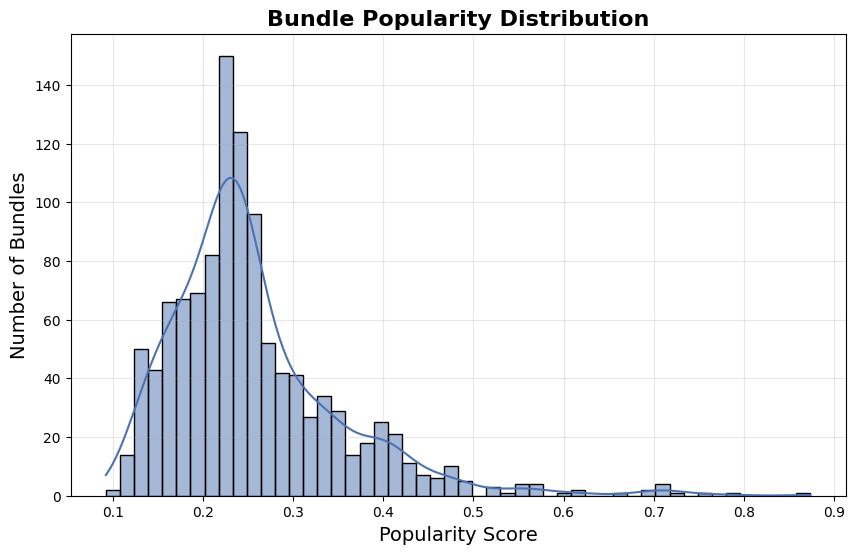

In [13]:
plt.figure(figsize=(10,6))
sns.histplot(prepared_data['predicted_popularity'], bins=50, kde=True, color="#4C72B0", edgecolor='black')
plt.title("Bundle Popularity Distribution", fontsize=16, fontweight='bold')
plt.xlabel("Popularity Score", fontsize=14)
plt.ylabel("Number of Bundles", fontsize=14)
plt.grid(alpha=0.3)
plt.show()

In [70]:
prepared_data = prepared_data[prepared_data['price'] > 0]

### Genetic Algorithm Modeling

In [74]:
population = prepared_data.copy()
print("The Candidate Solutions: ", population.shape[0])

The Candidate Solutions:  1035


In [75]:
population.head(10)

,bundle_name,bundle_type,price,usage_type,service_class_category,configured_volume_mb,configured_volume_min,configured_volume_sms,validity,validity_hours,is_illimite,predicted_popularity
0,Inbound Voice Acceleration 175 mins 30Jours@2400F,BUNDLE_VOICE,2400.0,CHARGED,PREPAID,0.0,175.0,0.0,30 days,720.0,0,0.201396
1,Int Bundle ASIA and AMERICA 30min 30jours@1200F,INT_BUNDLE_VOICE,1200.0,CHARGED,PREPAID,0.0,30.0,0.0,30 days,720.0,0,0.246380
5,MTNBIZ+ 150GB@35000F,BUNDLE_DATA,35000.0,CHARGED,HYBRID,153600.0,0.0,0.0,30 days,720.0,0,0.205877
6,Forfait appels Senegal 5 mins 30 jours@1200F,INT_BUNDLE_VOICE,1200.0,CHARGED,PREPAID,0.0,5.0,0.0,30 days,720.0,0,0.174614
7,Ndeko Mix 300Mins + 7GB 7 jours@11000F,BUNDLE_DATA,11000.0,CHARGED,PREPAID,7168.0,0.0,0.0,7 days,168.0,0,0.238171
8,Forfait appels Senegal 2 mins 30 jours @490F,INT_BUNDLE_VOICE,490.0,CHARGED,PREPAID,0.0,2.0,0.0,30 days,720.0,0,0.159268
9,Forfait LTE Business 30 jours 2 mbps@80050F,BUNDLE_DATA,80050.0,CHARGED,PREPAID,0.0,0.0,0.0,30 days,720.0,0,0.252609
10,NEW RESIDENTIAL@18500F,BUNDLE_DATA,18500.0,CHARGED,HYBRID,92160.0,0.0,0.0,30 days,720.0,0,0.211036
11,Forfait appels Liban 3 mins 45sec 30 jours@350F,INT_BUNDLE_VOICE,350.0,CHARGED,PREPAID,0.0,3.0,0.0,30 days,720.0,0,0.138308
12,SHart + Extra Entreprise H4@100700,BUNDLE_DATA,100700.0,CHARGED,NaN,10240.0,0.0,0.0,30 days,720.0,0,0.204923


In [16]:
# remove 'is_illimite' because this can be extracted from generatesd bundle.
population.drop(columns=['is_illimite'], inplace=True)

In [17]:
def fitnees(candidate: pd.Series) -> float:

    candidate = candidate.to_frame().T.copy()

    candidate["week_number"] = 1
    candidate["season"] = "spring"
    candidate['is_illimite'] = candidate['bundle_name'].apply(is_illimite)

    score = predict_bundle_popularity(
        candidate,
        model,
        te,
        st_model,
        pca,
        scaler,
        numeric_cols
    )

    return score[0]

fitnees(candidate=population.iloc[0])

np.float64(0.20139564795160073)

In [21]:
from dataclasses import dataclass

DECISION_COLS = [
    "bundle_type",
    "price",
    "usage_type",
    "service_class_category",
    "configured_volume_mb",
    "configured_volume_min",
    "configured_volume_sms",
    "validity",
    "validity_hours",
]

NUMERIC_COLS_GA = [
    "price",
    "configured_volume_mb",
    "configured_volume_min",
    "configured_volume_sms",
    "validity_hours",
]

CATEGORICAL_COLS_GA = [
    "bundle_type",
    "usage_type",
    "service_class_category",
    "validity",
]

@dataclass
class GAConfig:
    population_size: int = 120
    generations: int = 40
    elite_size: int = 10
    tournament_size: int = 4
    crossover_rate: float = 0.90
    mutation_rate: float = 0.20
    synthetic_ratio: float = 0.50
    random_seed: int = 42
    verbose: bool = True

In [51]:
class BundleGA:
    def __init__(self, historical_df: pd.DataFrame, fitness_func, config: GAConfig):
        self.df = historical_df.copy().reset_index(drop=True)
        self.fitness_func = fitness_func
        self.cfg = config
        self.rng = np.random.default_rng(config.random_seed)
        self.cache = {}

        # Keep only rows that have the decision columns
        self.df = self.df.dropna(subset=["bundle_type", "price", "validity_hours"]).copy()

        # Validity pairs observed in real catalog
        self.validity_pairs = (
            self.df[["validity", "validity_hours"]]
            .dropna()
            .drop_duplicates()
            .reset_index(drop=True)
        )

        # Allowed categories
        self.category_values = {
            col: [x for x in self.df[col].dropna().unique().tolist()]
            for col in CATEGORICAL_COLS_GA
        }

        # Global numeric bounds from observed catalog
        self.global_bounds = {}
        for col in NUMERIC_COLS_GA:
            s = self.df[col].dropna()
            if len(s) == 0:
                self.global_bounds[col] = (0.0, 1.0)
            else:
                q01, q99 = np.quantile(s, [0.01, 0.99])
                lo = max(0.0, float(q01 * 0.5))
                hi = float(q99 * 1.5 if q99 > 0 else s.max() * 1.5 + 1)
                self.global_bounds[col] = (lo, hi)

        # Type-specific stats
        self.type_stats = {}
        for bt, sub in self.df.groupby("bundle_type", dropna=False):
            stats = {}
            for col in NUMERIC_COLS_GA:
                s = sub[col].dropna()
                if len(s) == 0:
                    stats[col] = self.global_bounds[col]
                else:
                    q05, q95 = np.quantile(s, [0.05, 0.95])
                    lo = max(0.0, float(q05 * 0.5))
                    hi = float(q95 * 1.5 if q95 > 0 else s.max() * 1.5 + 1)
                    stats[col] = (lo, hi)

            stats["usage_type_values"] = (
                sub["usage_type"].dropna().value_counts().index.tolist()
                or self.category_values["usage_type"]
            )
            stats["service_class_values"] = (
                sub["service_class_category"].dropna().value_counts().index.tolist()
                or self.category_values["service_class_category"]
            )
            stats["validity_pairs"] = (
                sub[["validity", "validity_hours"]].dropna().drop_duplicates().reset_index(drop=True)
            )
            self.type_stats[bt] = stats

    # ------------------------------
    # Bundle naming bridge
    # ------------------------------
    def make_placeholder_name(self, row: pd.Series) -> str:
        bt = str(row.get("bundle_type", "")).upper()
        price = int(round(float(row.get("price", 0) or 0)))
        mb = max(0.0, float(row.get("configured_volume_mb", 0) or 0))
        mins = max(0.0, float(row.get("configured_volume_min", 0) or 0))
        sms = max(0.0, float(row.get("configured_volume_sms", 0) or 0))
        validity_hours = float(row.get("validity_hours", 0) or 0)

        has_data = mb > 0
        has_voice = mins > 0
        has_sms = sms > 0

        if has_data and (has_voice or has_sms):
            label = "Forfait Mix"
        elif "INT" in bt and has_voice:
            label = "Forfait International Voix"
        elif has_data:
            label = "Forfait Data"
        elif has_voice:
            label = "Forfait Voix"
        elif has_sms:
            label = "Forfait SMS"
        else:
            label = "Forfait"

        parts = []
        if has_data:
            if mb >= 1024:
                gb = mb / 1024.0
                gb_txt = f"{int(gb)}GB" if abs(gb - round(gb)) < 1e-9 else f"{gb:.1f}GB"
                parts.append(gb_txt)
            else:
                parts.append(f"{int(round(mb))}MB")
        if has_voice:
            parts.append(f"{int(round(mins))}Min")
        if has_sms:
            parts.append(f"{int(round(sms))}SMS")

        if validity_hours % 24 == 0 and validity_hours > 0:
            duration = f"{int(round(validity_hours / 24))} jours"
        else:
            duration = f"{int(round(validity_hours))}h"

        resource_txt = " + ".join(parts) if parts else "Standard"
        return f"{label} {resource_txt} {duration}@{price}F"

    # ------------------------------
    # Structural heuristics
    # ------------------------------
    def _is_data_type(self, bundle_type: str) -> bool:
        t = str(bundle_type).upper()
        return any(k in t for k in ["DATA", "LTE", "INTERNET"])

    def _is_voice_type(self, bundle_type: str) -> bool:
        t = str(bundle_type).upper()
        return any(k in t for k in ["VOICE", "VOIX", "CALL"])

    def _is_mix_type(self, bundle_type: str) -> bool:
        return "MIX" in str(bundle_type).upper()

    def _sample_validity_pair(self, bundle_type: str):
        pairs = self.type_stats.get(bundle_type, {}).get("validity_pairs")
        if pairs is not None and len(pairs) > 0:
            row = pairs.sample(1, random_state=int(self.rng.integers(0, 1_000_000))).iloc[0]
            return row["validity"], float(row["validity_hours"])

        row = self.validity_pairs.sample(1, random_state=int(self.rng.integers(0, 1_000_000))).iloc[0]
        return row["validity"], float(row["validity_hours"])

    def _clip_numeric(self, value, low, high, round_to=None):
        value = float(np.clip(value, low, high))
        if round_to is not None and round_to > 0:
            value = round(value / round_to) * round_to
        return max(0.0, value)

    def repair_candidate(self, row: pd.Series) -> pd.Series:
        row = row.copy()

        # Fill missing categorical fields
        if pd.isna(row.get("bundle_type")):
            row["bundle_type"] = self.rng.choice(self.category_values["bundle_type"])

        bt = row["bundle_type"]
        stats = self.type_stats.get(bt, {})

        if pd.isna(row.get("usage_type")):
            choices = stats.get("usage_type_values", self.category_values["usage_type"])
            row["usage_type"] = self.rng.choice(choices)

        if pd.isna(row.get("service_class_category")):
            choices = stats.get("service_class_values", self.category_values["service_class_category"])
            row["service_class_category"] = self.rng.choice(choices)

        # Validity must be one of real observed pairs
        v, vh = self._sample_validity_pair(bt)
        row["validity"] = v
        row["validity_hours"] = vh

        # Clip numerics by observed bounds
        price_lo, price_hi = stats.get("price", self.global_bounds["price"])
        mb_lo, mb_hi = stats.get("configured_volume_mb", self.global_bounds["configured_volume_mb"])
        min_lo, min_hi = stats.get("configured_volume_min", self.global_bounds["configured_volume_min"])
        sms_lo, sms_hi = stats.get("configured_volume_sms", self.global_bounds["configured_volume_sms"])

        row["price"] = self._clip_numeric(row.get("price", price_lo), price_lo, price_hi, round_to=10)
        row["configured_volume_mb"] = self._clip_numeric(row.get("configured_volume_mb", 0), mb_lo, mb_hi, round_to=1)
        row["configured_volume_min"] = self._clip_numeric(row.get("configured_volume_min", 0), min_lo, min_hi, round_to=1)
        row["configured_volume_sms"] = self._clip_numeric(row.get("configured_volume_sms", 0), sms_lo, sms_hi, round_to=1)

        # Type-aware cleanup
        is_data = self._is_data_type(bt)
        is_voice = self._is_voice_type(bt)
        is_mix = self._is_mix_type(bt)

        if is_data and not is_mix and not is_voice:
            row["configured_volume_min"] = 0.0
            row["configured_volume_sms"] = 0.0

        if is_voice and not is_mix and not is_data:
            row["configured_volume_mb"] = 0.0

        # Ensure at least one usable resource exists
        total_resources = (
            float(row["configured_volume_mb"])
            + float(row["configured_volume_min"])
            + float(row["configured_volume_sms"])
        )

        if total_resources <= 0:
            if is_data:
                row["configured_volume_mb"] = max(100.0, mb_lo if mb_lo > 0 else 500.0)
            elif is_voice:
                row["configured_volume_min"] = max(5.0, min_lo if min_lo > 0 else 10.0)
            else:
                # generic fallback: make it mix-like
                row["configured_volume_mb"] = 1024.0
                row["configured_volume_min"] = 10.0

        # Regenerate telecom-like placeholder name deterministically
        row["bundle_name"] = self.make_placeholder_name(row)

        # Optional: keep this column clean if it exists in your source df
        #if "predicted_popularity" in row.index:
        #    row["predicted_popularity"] = np.nan

        return row

    def initialize_population(self):
        hist = self.df.copy().reset_index(drop=True)
        historical_candidates = [
           hist.iloc[i].copy() for i in range(len(hist))
        ]
        return historical_candidates


    # ------------------------------
    # GA operators
    # ------------------------------
    def mutate(self, row: pd.Series) -> pd.Series:
        row = row.copy()

        # Small chance to switch bundle type
        if self.rng.random() < 0.08:
            row["bundle_type"] = self.rng.choice(self.category_values["bundle_type"])

        bt = row["bundle_type"]
        stats = self.type_stats.get(bt, {})

        # Mutate categoricals
        if self.rng.random() < self.cfg.mutation_rate:
            row["usage_type"] = self.rng.choice(stats.get("usage_type_values", self.category_values["usage_type"]))
        if self.rng.random() < self.cfg.mutation_rate:
            row["service_class_category"] = self.rng.choice(
                stats.get("service_class_values", self.category_values["service_class_category"])
            )
        if self.rng.random() < self.cfg.mutation_rate:
            row["validity"], row["validity_hours"] = self._sample_validity_pair(bt)

        # Mutate numerics with multiplicative noise
        for col, round_to in [
            ("price", 10),
            ("configured_volume_mb", 1),
            ("configured_volume_min", 1),
            ("configured_volume_sms", 1),
        ]:
            if self.rng.random() < self.cfg.mutation_rate:
                lo, hi = stats.get(col, self.global_bounds[col])
                current = float(row.get(col, lo) or 0)
                factor = self.rng.uniform(0.7, 1.3)
                row[col] = self._clip_numeric(current * factor, lo, hi, round_to=round_to)

        return self.repair_candidate(row)

    def crossover(self, parent1: pd.Series, parent2: pd.Series) -> pd.Series:
        child = parent1.copy()

        for col in ["bundle_type", "price", "usage_type", "service_class_category",
                    "configured_volume_mb", "configured_volume_min", "configured_volume_sms"]:
            if self.rng.random() < 0.5:
                child[col] = parent2[col]

        # validity + validity_hours should move together
        if self.rng.random() < 0.5:
            child["validity"] = parent2["validity"]
            child["validity_hours"] = parent2["validity_hours"]

        return self.repair_candidate(child)

    def tournament_select(self, population, scores):
        idx = self.rng.choice(len(population), size=self.cfg.tournament_size, replace=False)
        best_idx = idx[np.argmax([scores[i] for i in idx])]
        return population[best_idx]

    # ------------------------------
    # Fitness with penalties
    # ------------------------------
    def penalty(self, row: pd.Series) -> float:
        p = 0.0

        price = float(row["price"])
        mb = float(row["configured_volume_mb"])
        mins = float(row["configured_volume_min"])
        sms = float(row["configured_volume_sms"])

        if price <= 0:
            p += 1.0

        if (mb + mins + sms) <= 0:
            p += 1.0

        bt = str(row["bundle_type"]).upper()
        is_data = self._is_data_type(bt)
        is_voice = self._is_voice_type(bt)
        is_mix = self._is_mix_type(bt)

        # Soft business-policy penalties
        if is_data and not is_mix and not is_voice and (mins > 0 or sms > 0):
            p += 0.20
        if is_voice and not is_mix and not is_data and mb > 0:
            p += 0.20

        # Range penalties
        stats = self.type_stats.get(row["bundle_type"], {})
        for col in ["price", "configured_volume_mb", "configured_volume_min", "configured_volume_sms"]:
            lo, hi = stats.get(col, self.global_bounds[col])
            val = float(row[col])
            if val < lo:
                p += 0.10 + 0.10 * (lo - val) / (lo + 1e-6)
            if val > hi:
                p += 0.10 + 0.10 * (val - hi) / (hi + 1e-6)

        return p

    def _cache_key(self, row: pd.Series):
        key_cols = DECISION_COLS + ["bundle_name"]
        out = []
        for col in key_cols:
            val = row.get(col, None)
            if pd.isna(val):
                out.append(None)
            elif isinstance(val, (float, np.floating)):
                out.append(round(float(val), 4))
            else:
                out.append(str(val))
        return tuple(out)

    def score(self, row: pd.Series) -> float:
        row = self.repair_candidate(row)
        key = self._cache_key(row)
        if key in self.cache:
            return self.cache[key]

        raw_score = float(self.fitness_func(row))
        final_score = raw_score # - self.penalty(row)
        self.cache[key] = final_score
        return final_score

    # ------------------------------
    # Main GA loop
    # ------------------------------
    def run(self, top_k=5):
        population = self.initialize_population()
        history = []

        for gen in range(self.cfg.generations):
            scores = [self.score(ind) for ind in population]

            gen_best_idx = int(np.argmax(scores))
            gen_best_score = float(scores[gen_best_idx])

            history.append({
                "generation": gen,
                "best_score": gen_best_score,
                "mean_score": float(np.mean(scores)),
                "std_score": float(np.std(scores)),
            })

            if self.cfg.verbose:
                print(
                    f"Gen {gen:02d} | "
                    f"best={gen_best_score:.6f} | "
                    f"mean={np.mean(scores):.6f}"
                )

            ranked_idx = np.argsort(scores)[::-1]
            new_population = [population[i].copy() for i in ranked_idx[:self.cfg.elite_size]]

            while len(new_population) < self.cfg.population_size:
                p1 = self.tournament_select(population, scores)
                p2 = self.tournament_select(population, scores)

                if self.rng.random() < self.cfg.crossover_rate:
                    child = self.crossover(p1, p2)
                else:
                    child = p1.copy()

                child = self.mutate(child)
                new_population.append(child)

            population = new_population

        # Score final population
        final_scores = [self.score(ind) for ind in population]

        # Build dataframe of final candidates
        result_rows = []
        for ind, sc in zip(population, final_scores):
            row = ind.copy()
            row["ga_score"] = sc
            result_rows.append(row)

        results_df = pd.DataFrame(result_rows)

        # Remove duplicates by structure
        dedup_cols = [
            "bundle_type",
            "price",
            "usage_type",
            "service_class_category",
            "configured_volume_mb",
            "configured_volume_min",
            "configured_volume_sms",
            "validity_hours",
            "bundle_name",
        ]

        top_bundles_df = (
            results_df
            .sort_values("ga_score", ascending=False)
            .drop_duplicates(subset=dedup_cols)
            .head(top_k)
            .reset_index(drop=True)
        )

        history_df = pd.DataFrame(history)
        return top_bundles_df, history_df


cfg = GAConfig(
    population_size=population.shape[0],
    generations=40,
    elite_size=10,
    tournament_size=4,
    crossover_rate=0.90,
    mutation_rate=0.20,
    synthetic_ratio=0.50,
    random_seed=42,
    verbose=True,
)

ga = BundleGA(historical_df=prepared_data.sort_values(by='predicted_popularity', ascending=False)[0:500],
            fitness_func=fitnees, config=cfg)
top_5_bundles, history_df = ga.run(top_k=5)

top_5_bundles.head()

Gen 00 | best=0.485258 | mean=0.291787
Gen 01 | best=0.499401 | mean=0.321622
Gen 02 | best=0.502764 | mean=0.348679
Gen 03 | best=0.504350 | mean=0.357289
Gen 04 | best=0.504350 | mean=0.368997
Gen 05 | best=0.505773 | mean=0.372996
Gen 06 | best=0.504350 | mean=0.390470
Gen 07 | best=0.509540 | mean=0.406993
Gen 08 | best=0.504350 | mean=0.428649
Gen 09 | best=0.504350 | mean=0.446605
Gen 10 | best=0.515942 | mean=0.463838
Gen 11 | best=0.504350 | mean=0.474922
Gen 12 | best=0.504350 | mean=0.474596
Gen 13 | best=0.504350 | mean=0.477615
Gen 14 | best=0.504350 | mean=0.474920
Gen 15 | best=0.504350 | mean=0.471215
Gen 16 | best=0.504350 | mean=0.475771
Gen 17 | best=0.504350 | mean=0.475679
Gen 18 | best=0.504350 | mean=0.479048
Gen 19 | best=0.504350 | mean=0.475938
Gen 20 | best=0.504350 | mean=0.473460
Gen 21 | best=0.504350 | mean=0.474618
Gen 22 | best=0.504350 | mean=0.474268
Gen 23 | best=0.504350 | mean=0.471124
Gen 24 | best=0.504350 | mean=0.475444
Gen 25 | best=0.504350 | 

,bundle_name,bundle_type,price,usage_type,service_class_category,configured_volume_mb,configured_volume_min,configured_volume_sms,validity,validity_hours,is_illimite,predicted_popularity,ga_score
0,Forfait Voix 12Min 1 jours@90F,BUNDLE_VOICE,90,CHARGED,PREPAID,0.0,12.0,0.0,1 days,24.0,0,0.607812,0.504350
1,Forfait Voix 12Min 30 jours@90F,BUNDLE_VOICE,90,CHARGED,PREPAID,0.0,12.0,0.0,30 days,720.0,0,0.335068,0.504350
2,Forfait Voix 12Min 15 jours@90F,BUNDLE_VOICE,90,CHARGED,PREPAID,0.0,12.0,0.0,15 days,360.0,0,0.288828,0.500734
3,Forfait Voix 12Min 2 jours@90F,BUNDLE_VOICE,90,CHARGED,PREPAID,0.0,12.0,0.0,2 days,48.0,0,0.288828,0.500734
4,Forfait Voix 12Min 3 jours@90F,BUNDLE_VOICE,90,CHARGED,PREPAID,0.0,12.0,0.0,3 days,72.0,0,0.405165,0.500734


In [48]:
prepared_data.sort_values(by='predicted_popularity', ascending=False)[0:500]

,bundle_name,bundle_type,price,usage_type,service_class_category,configured_volume_mb,configured_volume_min,configured_volume_sms,validity,validity_hours,is_illimite,predicted_popularity
382,Forfait weekend 3.17GB 3jours@840F,BUNDLE_DATA,840.0,CHARGED,PREPAID,3246.08,0.0,0.0,3 days,72.0,0,0.874050
1410,MaGicvoice 51Mins 1 jour@450F,BUNDLE_VOICE,450.0,CHARGED,PREPAID,0.00,51.0,0.0,1 days,24.0,0,0.782708
36,MaGicvoice 40+3Mins 7 jours@525F,BUNDLE_VOICE,525.0,CHARGED,PREPAID,0.00,43.0,0.0,7 days,168.0,0,0.750946
820,Forfait widge 1005.47MB 3 jours@660F upsell,BUNDLE_DATA,660.0,CHARGED,PREPAID,1005.47,0.0,0.0,3 days,72.0,0,0.726307
1064,Forfait Maxivoice 10Mins 1 jour@150F,BUNDLE_VOICE,150.0,CHARGED,PREPAID,0.00,10.0,0.0,1 days,24.0,0,0.712124
...,...,...,...,...,...,...,...,...,...,...,...,...
644,New Zone A and B NDAKO 4G 220GB 30 Jours@18000F,BUNDLE_DATA,18000.0,CHARGED,PREPAID,225280.00,0.0,0.0,30 days,720.0,0,0.243891
195,Forfait tous reseaux 456 mins 30 jour@20500F,BUNDLE_VOICE,20500.0,CHARGED,NaN,0.00,0.0,0.0,30 days,720.0,0,0.243816
929,Maxivoice 9mins+ Gagne ton taxi 1 jour@150F,BUNDLE_VOICE,150.0,CHARGED,PREPAID,0.00,9.0,0.0,1 days,24.0,0,0.243802
168,Forfait MTNBIZ+45 45GB 30 Jours@16000F,BUNDLE_DATA,16000.0,CHARGED,PREPAID,46080.00,0.0,0.0,30 days,720.0,0,0.243612


In [47]:
print("\nTop optimization history:")
history_df.tail()


Top optimization history:


,generation,best_score,mean_score,std_score
35,35,0.50435,0.470926,0.068830
36,36,0.50435,0.468757,0.075690
37,37,0.50435,0.474404,0.063841
38,38,0.50435,0.475328,0.062850
39,39,0.50435,0.474743,0.064799


In [ ]:
import math

PRICING_CONFIG = {
    'services': {
        'voice': {
            'anchor_price': 200,
            'anchor_rate': 13.3,
            'floor_rate': 6.0,
            'max_price': 10000,
            'unit_name': 'Minutes',
            'daily_points': [
                [100, 20.0], [150, 16.67], [175, 15.91], [200, 12.5], [220, 12.22],
                [230, 12.11], [300, 10.71], [450, 8.82], [540, 8.44], [750, 7.14], [800, 6.67]
            ],
            'weekly_points': [
                [300, 18.75], [420, 14.0], [525, 12.21], [650, 10.83], [750, 10.0],
                [840, 9.13], [935, 8.90], [1650, 7.5], [3520, 7.04], [5000, 6.25], [5390, 6.19]
            ],
            'decay_k': None
        },
        'data': {
            'anchor_price': 650,
            'anchor_rate': 0.42,
            'floor_rate': 0.2,
            'max_price': 10000,
            'unit_name': 'MB',
            'daily_points': [
                [100, 2.0], [190, 1.583], [220, 1.294], [290, 1.16], [650, 0.42]
            ],
            'decay_k': None
        },
        'sms': {
            'anchor_price': 50,
            'anchor_rate': 1.3,
            'floor_rate': 0.2,
            'max_price': 500,
            'unit_name': 'SMS',
            'decay_k': None
        }
    },
    'validity_premiums': {
        1: 0,
        2: 25,
        3: 50,
        7: 120,
        30: 235
    },
    'mixed_bundle_discounts': {
        1: 0,
        2: 10,
        3: 20
    },
    'btl_discounts': {
        'atl': 0,
        'diy_mode': -5,
        'promotion_mode':0,
        'btl_normal': 20,
        'btl_moderate': 30,
        'btl_aggressive': 40
    },
    'rounding_rules': {
        'data_round_to': 5
    },
    'minimums': {
        'price': {'voice': 100, 'data': 100},
        'volume': {'voice': 5, 'data': 50},
        'multi_service_volume': {'voice': 5, 'data': 50, 'sms': 0}
    },
    'promotion_mode_param': {
        'voice': {'starting_price': 150, 'ending_price': 2000,'discount':35,'validity':-1},
        'data': {'starting_price': 0, 'ending_price': 0,'discount':0,'validity':-1},
        'sms': {'starting_price': 0, 'ending_price': 0,'discount':0,'validity':-1},
    }
}

def recalculate_decay(anchor_price, anchor_rate, floor_rate, max_price):
    if anchor_rate <= floor_rate or max_price <= anchor_price:
        return math.nan
    rate_at_max = floor_rate + 0.01
    numerator = math.log((rate_at_max - floor_rate) / (anchor_rate - floor_rate))
    denominator = max_price - anchor_price
    return -numerator / denominator

def interpolate(x, points):
    if x < points[0][0]:
        x1, y1 = points[0]
        x2, y2 = points[1]
        slope = (y2 - y1) / (x2 - x1) if (x2 - x1) != 0 else 0
        return y1 + (x - x1) * slope
    for i in range(len(points) - 1):
        x1, y1 = points[i]
        x2, y2 = points[i + 1]
        if x1 <= x < x2:
            return y1 + (x - x1) * (y2 - y1) / (x2 - x1)
    return points[-1][1]

def get_vpm(validity_days, premiums_config):
    points = sorted([[int(k), v] for k, v in premiums_config.items()])
    premium = interpolate(validity_days, points)
    return 1 + premium / 100.0

def calculate_volume_from_price(price, service, validity_days, num_services, offer_type, config,mbdf_per):
    s_config = config['services'][service]
 
    mbdf = 1 - (mbdf_per * config['mixed_bundle_discounts'].get(2, 0) / 100.0)
    starting_price = config['promotion_mode_param'][service].get('starting_price',0)
    ending_price = config['promotion_mode_param'][service].get('ending_price',0)
    promo_val = config['promotion_mode_param'][service].get('validity',0)
    if num_services == 1  and offer_type == 'promotion_mode' and price >= starting_price  and price <= ending_price and (promo_val==-1 or promo_val == validity_days ): 
        tdf = 1 - (config['promotion_mode_param'][service].get('discount', 0) / 100.0) 
    else:
        tdf = 1 - (config['btl_discounts'].get(offer_type, 0) / 100.0)

    
    if s_config.get('decay_k') is None:
        s_config['decay_k'] = recalculate_decay(
            s_config['anchor_price'], s_config['anchor_rate'],
            s_config['floor_rate'], s_config['max_price'])

    final_er = 0
    if service == 'voice':
        points = s_config['weekly_points'] if validity_days == 7 else s_config['daily_points']
        last_price_point = points[-1][0]
        er_price = 0
        if price > last_price_point:
            k = s_config['decay_k']
            er_price = s_config['floor_rate'] + (points[-1][1] - s_config['floor_rate']) * math.exp(-k * (price - last_price_point))
        else:
            er_price = interpolate(price, points)
        final_er = er_price if validity_days == 7 else er_price * get_vpm(validity_days, config['validity_premiums'])
    elif service == 'data':
        er_price_base = 0
        if price <= s_config['anchor_price']:
            er_price_base = interpolate(price, s_config['daily_points'])
        else:
            k = s_config['decay_k']
            er_price_base = s_config['floor_rate'] + (s_config['anchor_rate'] - s_config['floor_rate']) * math.exp(-k * (price - s_config['anchor_price']))
        final_er = er_price_base * get_vpm(validity_days, config['validity_premiums'])
    else: # sms
        k = s_config['decay_k']
        er_price = s_config['floor_rate'] + (s_config['anchor_rate'] - s_config['floor_rate']) * math.exp(-k * (price - s_config['anchor_price']))
        final_er = er_price * get_vpm(validity_days, config['validity_premiums'])

    ultimate_er = final_er * mbdf * tdf

    return price / ultimate_er if ultimate_er > 0 else 0

def calculate_bundle(service_allocations, validity_days, offer_type, config):
    active_services = {s: p for s, p in service_allocations.items() if p > 0}
    num_services = len(active_services)
    
    sorted_keys = sorted(active_services, key=active_services.get)
    smallest_ser = {k: (1 if i < num_services-1 else 0) for i, k in enumerate(sorted_keys)}
    active_services = {s: p for s, p in service_allocations.items() if p > 0}
    num_services = len(active_services)
    final_offer = {'units': {}}

    for service, price in active_services.items():
        unrounded_units = calculate_volume_from_price(price, service, validity_days, num_services, offer_type, config,smallest_ser[service])
        s_config = config['services'][service]
        
        if service == 'data':
            rounded_units = math.ceil(unrounded_units / config['rounding_rules']['data_round_to']) * config['rounding_rules']['data_round_to']
        else:
            rounded_units = round(unrounded_units)
        
        final_offer['units'][service] = f"{rounded_units} {s_config['unit_name']}"
    
    return final_offer

def find_price_for_volume(service, target_volume, validity_days, offer_type, num_services, config,mbdf_per):
    s_config = config['services'][service]
    low_price, high_price = 0.01, s_config['max_price']

    def get_rounded_volume(price_guess):
        unrounded_units = calculate_volume_from_price(price_guess, service, validity_days, num_services, offer_type, config,mbdf_per)
        if service == 'data':
            return math.ceil(unrounded_units / config['rounding_rules']['data_round_to']) * config['rounding_rules']['data_round_to']
        else:
            return round(unrounded_units)

    for _ in range(100):
        guess_price = (low_price + high_price) / 2
        rounded_units = get_rounded_volume(guess_price)
        if rounded_units < target_volume:
            low_price = guess_price
        else:
            high_price = guess_price
        if (high_price - low_price) < 0.001:
            break
            
    return high_price

def calculate_price_from_volume(target_volumes, validity_days, offer_type, config):
    active_services = {s: v for s, v in target_volumes.items() if v > 0}
    num_services = len(active_services)
    service_prices = {
    service: active_services[service] * PRICING_CONFIG['services'][service]['anchor_rate']
                    for service in active_services  }

    sorted_keys = sorted(service_prices, key=service_prices.get)
    smallest_ser = {k: (1 if i < num_services-1 else 0) for i, k in enumerate(sorted_keys)}


    if num_services > 1:
        for service, volume in active_services.items():
            min_vol = config['minimums']['multi_service_volume'].get(service)
            if min_vol and volume < min_vol:
                return {'error': f"Error: Minimum for {service} in a multi-buy is {min_vol}."}

    individual_prices = {}
    sub_total_price = 0
    for service, volume in active_services.items():
        price = find_price_for_volume(service, volume, validity_days, offer_type, num_services, config,smallest_ser[service])
        
        min_price = config['minimums']['price'].get(service)
        final_price = price if min_price is None or price >= min_price else min_price
        
        individual_prices[service] = final_price
        sub_total_price += final_price
    
    final_total_price = round(sub_total_price)
    
    return {
        'calculated_price': final_total_price,
        'individual_prices': individual_prices
    }

In [ ]:
import math
import numpy as np
import pandas as pd


class BundleGA:
    def __init__(self, historical_df: pd.DataFrame, fitness_func, config: GAConfig):
        self.df = historical_df.copy().reset_index(drop=True)
        self.fitness_func = fitness_func
        self.cfg = config
        self.rng = np.random.default_rng(config.random_seed)
        self.cache = {}

        self.df = self.df.dropna(subset=["bundle_type", "price", "validity_hours"]).copy()

        self.validity_pairs = (
            self.df[["validity", "validity_hours"]]
            .dropna()
            .drop_duplicates()
            .reset_index(drop=True)
        )

        self.category_values = {
            col: [x for x in self.df[col].dropna().unique().tolist()]
            for col in CATEGORICAL_COLS_GA
        }

        self.global_bounds = {}
        for col in NUMERIC_COLS_GA:
            s = self.df[col].dropna()
            if len(s) == 0:
                self.global_bounds[col] = (0.0, 1.0)
            else:
                q01, q99 = np.quantile(s, [0.01, 0.99])
                lo = max(0.0, float(q01 * 0.5))
                hi = float(q99 * 1.5 if q99 > 0 else s.max() * 1.5 + 1)
                self.global_bounds[col] = (lo, hi)

        self.type_stats = {}
        for bt, sub in self.df.groupby("bundle_type", dropna=False):
            stats = {}
            for col in NUMERIC_COLS_GA:
                s = sub[col].dropna()
                if len(s) == 0:
                    stats[col] = self.global_bounds[col]
                else:
                    q05, q95 = np.quantile(s, [0.05, 0.95])
                    lo = max(0.0, float(q05 * 0.5))
                    hi = float(q95 * 1.5 if q95 > 0 else s.max() * 1.5 + 1)
                    stats[col] = (lo, hi)

            stats["usage_type_values"] = (
                sub["usage_type"].dropna().value_counts().index.tolist()
                or self.category_values["usage_type"]
            )
            stats["service_class_values"] = (
                sub["service_class_category"].dropna().value_counts().index.tolist()
                or self.category_values["service_class_category"]
            )
            stats["validity_pairs"] = (
                sub[["validity", "validity_hours"]]
                .dropna()
                .drop_duplicates()
                .reset_index(drop=True)
            )
            self.type_stats[bt] = stats

    # ------------------------------
    # Bundle naming bridge
    # ------------------------------
    def make_placeholder_name(self, row: pd.Series) -> str:
        bt = str(row.get("bundle_type", "")).upper()
        price = int(round(float(row.get("price", 0) or 0)))
        mb = max(0.0, float(row.get("configured_volume_mb", 0) or 0))
        mins = max(0.0, float(row.get("configured_volume_min", 0) or 0))
        sms = max(0.0, float(row.get("configured_volume_sms", 0) or 0))
        validity_hours = float(row.get("validity_hours", 0) or 0)

        has_data = mb > 0
        has_voice = mins > 0
        has_sms = sms > 0

        if has_data and (has_voice or has_sms):
            label = "Forfait Mix"
        elif "INT" in bt and has_voice:
            label = "Forfait International Voix"
        elif has_data:
            label = "Forfait Data"
        elif has_voice:
            label = "Forfait Voix"
        elif has_sms:
            label = "Forfait SMS"
        else:
            label = "Forfait"

        parts = []
        if has_data:
            if mb >= 1024:
                gb = mb / 1024.0
                gb_txt = f"{int(gb)}GB" if abs(gb - round(gb)) < 1e-9 else f"{gb:.1f}GB"
                parts.append(gb_txt)
            else:
                parts.append(f"{int(round(mb))}MB")
        if has_voice:
            parts.append(f"{int(round(mins))}Min")
        if has_sms:
            parts.append(f"{int(round(sms))}SMS")

        if validity_hours % 24 == 0 and validity_hours > 0:
            duration = f"{int(round(validity_hours / 24))} jours"
        else:
            duration = f"{int(round(validity_hours))}h"

        resource_txt = " + ".join(parts) if parts else "Standard"
        return f"{label} {resource_txt} {duration}@{price}F"

    # ------------------------------
    # Structural heuristics
    # ------------------------------
    def _is_data_type(self, bundle_type: str) -> bool:
        t = str(bundle_type).upper()
        return any(k in t for k in ["DATA", "LTE", "INTERNET"])

    def _is_voice_type(self, bundle_type: str) -> bool:
        t = str(bundle_type).upper()
        return any(k in t for k in ["VOICE", "VOIX", "CALL"])

    def _is_mix_type(self, bundle_type: str) -> bool:
        return "MIX" in str(bundle_type).upper()

    def _sample_validity_pair(self, bundle_type: str):
        pairs = self.type_stats.get(bundle_type, {}).get("validity_pairs")
        if pairs is not None and len(pairs) > 0:
            row = pairs.sample(1, random_state=int(self.rng.integers(0, 1_000_000))).iloc[0]
            return row["validity"], float(row["validity_hours"])

        row = self.validity_pairs.sample(1, random_state=int(self.rng.integers(0, 1_000_000))).iloc[0]
        return row["validity"], float(row["validity_hours"])

    def _clip_numeric(self, value, low, high, round_to=None):
        value = float(np.clip(value, low, high))
        if round_to is not None and round_to > 0:
            value = round(value / round_to) * round_to
        return max(0.0, value)

    # ------------------------------
    # Pricing bridge
    # ------------------------------
    def _validity_days_from_row(self, row: pd.Series) -> int:
        validity_hours = float(row.get("validity_hours", 0) or 0)
        if validity_hours > 0:
            return max(1, int(math.ceil(validity_hours / 24.0)))

        validity = row.get("validity", 1)
        try:
            return max(1, int(round(float(validity))))
        except Exception:
            return 1

    def _offer_type_from_row(self, row: pd.Series) -> str:
        for col in ["offer_type", "usage_type"]:
            val = row.get(col)
            if pd.notna(val):
                normalized = str(val).strip().lower()
                if normalized in PRICING_CONFIG["btl_discounts"]:
                    return normalized
        return "atl"

    def _target_volumes_from_row(self, row: pd.Series):
        return {
            "voice": max(0, int(round(float(row.get("configured_volume_min", 0) or 0)))),
            "data": max(0, int(round(float(row.get("configured_volume_mb", 0) or 0)))),
            "sms": max(0, int(round(float(row.get("configured_volume_sms", 0) or 0)))),
        }

    def _apply_pricing_minimums(self, row: pd.Series) -> pd.Series:
        row = row.copy()
        targets = self._target_volumes_from_row(row)
        active_services = [s for s, v in targets.items() if v > 0]

        if len(active_services) > 1:
            multi_min = PRICING_CONFIG["minimums"]["multi_service_volume"]

            if targets["voice"] > 0 and targets["voice"] < multi_min.get("voice", 0):
                row["configured_volume_min"] = float(multi_min["voice"])

            if targets["data"] > 0 and targets["data"] < multi_min.get("data", 0):
                row["configured_volume_mb"] = float(multi_min["data"])

            if targets["sms"] > 0 and targets["sms"] < multi_min.get("sms", 0):
                row["configured_volume_sms"] = float(multi_min["sms"])

        return row

    def _derive_price(self, row: pd.Series) -> float:
        target_volumes = self._target_volumes_from_row(row)
        validity_days = self._validity_days_from_row(row)
        offer_type = self._offer_type_from_row(row)

        result = calculate_price_from_volume(
            target_volumes=target_volumes,
            validity_days=validity_days,
            offer_type=offer_type,
            config=PRICING_CONFIG,
        )

        if "error" in result:
            result = calculate_price_from_volume(
                target_volumes=target_volumes,
                validity_days=validity_days,
                offer_type="atl",
                config=PRICING_CONFIG,
            )

        if "error" in result:
            return max(0.0, float(row.get("price", 0) or 0))

        return float(result["calculated_price"])

    def repair_candidate(self, row: pd.Series) -> pd.Series:
        row = row.copy()

        if pd.isna(row.get("bundle_type")):
            row["bundle_type"] = self.rng.choice(self.category_values["bundle_type"])

        bt = row["bundle_type"]
        stats = self.type_stats.get(bt, {})

        if pd.isna(row.get("usage_type")):
            choices = stats.get("usage_type_values", self.category_values["usage_type"])
            row["usage_type"] = self.rng.choice(choices)

        if pd.isna(row.get("service_class_category")):
            choices = stats.get("service_class_values", self.category_values["service_class_category"])
            row["service_class_category"] = self.rng.choice(choices)

        v, vh = self._sample_validity_pair(bt)
        row["validity"] = v
        row["validity_hours"] = vh

        mb_lo, mb_hi = stats.get("configured_volume_mb", self.global_bounds["configured_volume_mb"])
        min_lo, min_hi = stats.get("configured_volume_min", self.global_bounds["configured_volume_min"])
        sms_lo, sms_hi = stats.get("configured_volume_sms", self.global_bounds["configured_volume_sms"])

        row["configured_volume_mb"] = self._clip_numeric(row.get("configured_volume_mb", 0), mb_lo, mb_hi, round_to=1)
        row["configured_volume_min"] = self._clip_numeric(row.get("configured_volume_min", 0), min_lo, min_hi, round_to=1)
        row["configured_volume_sms"] = self._clip_numeric(row.get("configured_volume_sms", 0), sms_lo, sms_hi, round_to=1)

        is_data = self._is_data_type(bt)
        is_voice = self._is_voice_type(bt)
        is_mix = self._is_mix_type(bt)

        if is_data and not is_mix and not is_voice:
            row["configured_volume_min"] = 0.0
            row["configured_volume_sms"] = 0.0

        if is_voice and not is_mix and not is_data:
            row["configured_volume_mb"] = 0.0

        total_resources = (
            float(row["configured_volume_mb"])
            + float(row["configured_volume_min"])
            + float(row["configured_volume_sms"])
        )

        if total_resources <= 0:
            if is_data:
                row["configured_volume_mb"] = max(100.0, mb_lo if mb_lo > 0 else 500.0)
            elif is_voice:
                row["configured_volume_min"] = max(5.0, min_lo if min_lo > 0 else 10.0)
            else:
                row["configured_volume_mb"] = 1024.0
                row["configured_volume_min"] = 10.0

        row = self._apply_pricing_minimums(row)

        # Price is always derived from the trusted pricing algorithm.
        row["price"] = self._derive_price(row)

        row["bundle_name"] = self.make_placeholder_name(row)

        return row

    def initialize_population(self):
        hist = self.df.copy().reset_index(drop=True)
        historical_candidates = [
            self.repair_candidate(hist.iloc[i].copy()) for i in range(len(hist))
        ]
        return historical_candidates

    # ------------------------------
    # GA operators
    # ------------------------------
    def mutate(self, row: pd.Series) -> pd.Series:
        row = row.copy()

        if self.rng.random() < 0.08:
            row["bundle_type"] = self.rng.choice(self.category_values["bundle_type"])

        bt = row["bundle_type"]
        stats = self.type_stats.get(bt, {})

        if self.rng.random() < self.cfg.mutation_rate:
            row["usage_type"] = self.rng.choice(
                stats.get("usage_type_values", self.category_values["usage_type"])
            )

        if self.rng.random() < self.cfg.mutation_rate:
            row["service_class_category"] = self.rng.choice(
                stats.get("service_class_values", self.category_values["service_class_category"])
            )

        if self.rng.random() < self.cfg.mutation_rate:
            row["validity"], row["validity_hours"] = self._sample_validity_pair(bt)

        for col, round_to in [
            ("configured_volume_mb", 1),
            ("configured_volume_min", 1),
            ("configured_volume_sms", 1),
        ]:
            if self.rng.random() < self.cfg.mutation_rate:
                lo, hi = stats.get(col, self.global_bounds[col])
                current = float(row.get(col, lo) or 0)
                factor = self.rng.uniform(0.7, 1.3)
                row[col] = self._clip_numeric(current * factor, lo, hi, round_to=round_to)

        return self.repair_candidate(row)

    def crossover(self, parent1: pd.Series, parent2: pd.Series) -> pd.Series:
        child = parent1.copy()

        for col in [
            "bundle_type",
            "usage_type",
            "service_class_category",
            "configured_volume_mb",
            "configured_volume_min",
            "configured_volume_sms",
        ]:
            if self.rng.random() < 0.5:
                child[col] = parent2[col]

        if self.rng.random() < 0.5:
            child["validity"] = parent2["validity"]
            child["validity_hours"] = parent2["validity_hours"]

        return self.repair_candidate(child)

    def tournament_select(self, population, scores):
        idx = self.rng.choice(len(population), size=self.cfg.tournament_size, replace=False)
        best_idx = idx[np.argmax([scores[i] for i in idx])]
        return population[best_idx]

    # ------------------------------
    # Fitness with penalties
    # ------------------------------
    def penalty(self, row: pd.Series) -> float:
        p = 0.0

        price = float(row["price"])
        mb = float(row["configured_volume_mb"])
        mins = float(row["configured_volume_min"])
        sms = float(row["configured_volume_sms"])

        if price <= 0:
            p += 1.0

        if (mb + mins + sms) <= 0:
            p += 1.0

        bt = str(row["bundle_type"]).upper()
        is_data = self._is_data_type(bt)
        is_voice = self._is_voice_type(bt)
        is_mix = self._is_mix_type(bt)

        if is_data and not is_mix and not is_voice and (mins > 0 or sms > 0):
            p += 0.20
        if is_voice and not is_mix and not is_data and mb > 0:
            p += 0.20

        for col in ["configured_volume_mb", "configured_volume_min", "configured_volume_sms"]:
            lo, hi = self.type_stats.get(row["bundle_type"], {}).get(col, self.global_bounds[col])
            val = float(row[col])
            if val < lo:
                p += 0.10 + 0.10 * (lo - val) / (lo + 1e-6)
            if val > hi:
                p += 0.10 + 0.10 * (val - hi) / (hi + 1e-6)

        return p

    def _cache_key(self, row: pd.Series):
        key_cols = DECISION_COLS + ["bundle_name"]
        out = []
        for col in key_cols:
            val = row.get(col, None)
            if pd.isna(val):
                out.append(None)
            elif isinstance(val, (float, np.floating)):
                out.append(round(float(val), 4))
            else:
                out.append(str(val))
        return tuple(out)

    def score(self, row: pd.Series) -> float:
        row = self.repair_candidate(row)
        key = self._cache_key(row)
        if key in self.cache:
            return self.cache[key]

        raw_score = float(self.fitness_func(row))
        final_score = raw_score
        self.cache[key] = final_score
        return final_score

    # ------------------------------
    # Main GA loop
    # ------------------------------
    def run(self, top_k=5):
        population = self.initialize_population()
        history = []

        for gen in range(self.cfg.generations):
            scores = [self.score(ind) for ind in population]

            gen_best_idx = int(np.argmax(scores))
            gen_best_score = float(scores[gen_best_idx])

            history.append({
                "generation": gen,
                "best_score": gen_best_score,
                "mean_score": float(np.mean(scores)),
                "std_score": float(np.std(scores)),
            })

            if self.cfg.verbose:
                print(
                    f"Gen {gen:02d} | "
                    f"best={gen_best_score:.6f} | "
                    f"mean={np.mean(scores):.6f}"
                )

            ranked_idx = np.argsort(scores)[::-1]
            new_population = [population[i].copy() for i in ranked_idx[:self.cfg.elite_size]]

            while len(new_population) < self.cfg.population_size:
                p1 = self.tournament_select(population, scores)
                p2 = self.tournament_select(population, scores)

                if self.rng.random() < self.cfg.crossover_rate:
                    child = self.crossover(p1, p2)
                else:
                    child = p1.copy()

                child = self.mutate(child)
                new_population.append(child)

            population = new_population

        final_scores = [self.score(ind) for ind in population]

        result_rows = []
        for ind, sc in zip(population, final_scores):
            row = ind.copy()
            row["ga_score"] = sc
            result_rows.append(row)

        results_df = pd.DataFrame(result_rows)

        dedup_cols = [
            "bundle_type",
            "price",
            "usage_type",
            "service_class_category",
            "configured_volume_mb",
            "configured_volume_min",
            "configured_volume_sms",
            "validity_hours",
            "bundle_name",
        ]

        top_bundles_df = (
            results_df
            .sort_values("ga_score", ascending=False)
            .drop_duplicates(subset=dedup_cols)
            .head(top_k)
            .reset_index(drop=True)
        )

        history_df = pd.DataFrame(history)
        return top_bundles_df, history_df


cfg = GAConfig(
    population_size=population.shape[0],
    generations=40,
    elite_size=10,
    tournament_size=4,
    crossover_rate=0.90,
    mutation_rate=0.20,
    synthetic_ratio=0.50,
    random_seed=42,
    verbose=True,
)

ga = BundleGA(
    historical_df=prepared_data.sort_values(by="predicted_popularity", ascending=False)[0:500],
    fitness_func=fitnees,
    config=cfg,
)

top_5_bundles, history_df = ga.run(top_k=5)
top_5_bundles.head()


Gen 00 | best=0.463986 | mean=0.290737
Gen 01 | best=0.477419 | mean=0.337945
Gen 02 | best=0.492696 | mean=0.350469
Gen 03 | best=0.493589 | mean=0.367405
Gen 04 | best=0.493589 | mean=0.393567
Gen 05 | best=0.477419 | mean=0.424419
Gen 06 | best=0.477419 | mean=0.446406
Gen 07 | best=0.477419 | mean=0.445939
Gen 08 | best=0.473154 | mean=0.449799
Gen 09 | best=0.468409 | mean=0.448867
Gen 10 | best=0.468409 | mean=0.452279
Gen 11 | best=0.468409 | mean=0.452865
Gen 12 | best=0.468409 | mean=0.453123
Gen 13 | best=0.473154 | mean=0.447157
Gen 14 | best=0.468409 | mean=0.450758
Gen 15 | best=0.468409 | mean=0.454828
Gen 16 | best=0.468409 | mean=0.451732
Gen 17 | best=0.468409 | mean=0.454060
Gen 18 | best=0.468409 | mean=0.450553
Gen 19 | best=0.473154 | mean=0.452867
Gen 20 | best=0.468409 | mean=0.451014
Gen 21 | best=0.468409 | mean=0.454222
Gen 22 | best=0.468409 | mean=0.449238
Gen 23 | best=0.468409 | mean=0.450520
Gen 24 | best=0.468300 | mean=0.454214
Gen 25 | best=0.473154 | 

,bundle_name,bundle_type,price,usage_type,service_class_category,configured_volume_mb,configured_volume_min,configured_volume_sms,validity,validity_hours,is_illimite,predicted_popularity,ga_score
0,Forfait Voix 4Min 1 jours@100F,BUNDLE_VOICE,100.0,CHARGED,PREPAID,0.0,4.0,0.0,1 days,24.0,0,0.437079,0.468409
1,Forfait Voix 4Min 3 jours@104F,BUNDLE_VOICE,104.0,CHARGED,PREPAID,0.0,4.0,0.0,3 days,72.0,0,0.280818,0.468409
2,Forfait Voix 4Min 1 jours@100F,OFFNET_BUNDLE_VOICE,100.0,CHARGED,PREPAID,0.0,4.0,0.0,1 days,24.0,0,0.324669,0.468300
3,Forfait Voix 4Min 2 jours@100F,BUNDLE_VOICE,100.0,CHARGED,PREPAID,0.0,4.0,0.0,2 days,48.0,0,0.325286,0.456868
4,Forfait Voix 4Min 30 jours@179F,BUNDLE_VOICE,179.0,CHARGED,PREPAID,0.0,4.0,0.0,30 days,720.0,0,0.419701,0.449451


In [54]:
prepared_data.sort_values(by="predicted_popularity", ascending=False)[0:500]

,bundle_name,bundle_type,price,usage_type,service_class_category,configured_volume_mb,configured_volume_min,configured_volume_sms,validity,validity_hours,is_illimite,predicted_popularity
382,Forfait weekend 3.17GB 3jours@840F,BUNDLE_DATA,840.0,CHARGED,PREPAID,3246.08,0.0,0.0,3 days,72.0,0,0.874050
1410,MaGicvoice 51Mins 1 jour@450F,BUNDLE_VOICE,450.0,CHARGED,PREPAID,0.00,51.0,0.0,1 days,24.0,0,0.782708
36,MaGicvoice 40+3Mins 7 jours@525F,BUNDLE_VOICE,525.0,CHARGED,PREPAID,0.00,43.0,0.0,7 days,168.0,0,0.750946
820,Forfait widge 1005.47MB 3 jours@660F upsell,BUNDLE_DATA,660.0,CHARGED,PREPAID,1005.47,0.0,0.0,3 days,72.0,0,0.726307
1064,Forfait Maxivoice 10Mins 1 jour@150F,BUNDLE_VOICE,150.0,CHARGED,PREPAID,0.00,10.0,0.0,1 days,24.0,0,0.712124
...,...,...,...,...,...,...,...,...,...,...,...,...
644,New Zone A and B NDAKO 4G 220GB 30 Jours@18000F,BUNDLE_DATA,18000.0,CHARGED,PREPAID,225280.00,0.0,0.0,30 days,720.0,0,0.243891
195,Forfait tous reseaux 456 mins 30 jour@20500F,BUNDLE_VOICE,20500.0,CHARGED,NaN,0.00,0.0,0.0,30 days,720.0,0,0.243816
929,Maxivoice 9mins+ Gagne ton taxi 1 jour@150F,BUNDLE_VOICE,150.0,CHARGED,PREPAID,0.00,9.0,0.0,1 days,24.0,0,0.243802
168,Forfait MTNBIZ+45 45GB 30 Jours@16000F,BUNDLE_DATA,16000.0,CHARGED,PREPAID,46080.00,0.0,0.0,30 days,720.0,0,0.243612


In [ ]:
6,387,170,816

In [67]:

prepared_data[prepared_data['price'] == prepared_data['price'].min()]

,bundle_name,bundle_type,price,usage_type,service_class_category,configured_volume_mb,configured_volume_min,configured_volume_sms,validity,validity_hours,is_illimite,predicted_popularity
20,Forfait Smart PLUS Entreprise H3,BUNDLE_DATA,-1.0,CHARGED,NaN,5120.0,0.0,0.0,30 days,720.0,0,0.267081
115,Forfait Smart PLUS Entreprise M2,BUNDLE_DATA,-1.0,CHARGED,NaN,1024.0,0.0,0.0,30 days,720.0,0,0.283680
244,Forfait Smart PLUS Entreprise L3,BUNDLE_DATA,-1.0,CHARGED,NaN,500.0,0.0,0.0,30 days,720.0,0,0.283885
372,Forfait Smart PLUS Entreprise M1,BUNDLE_DATA,-1.0,CHARGED,NaN,1024.0,0.0,0.0,30 days,720.0,0,0.273396
402,Forfait Smart Entreprise H2,BUNDLE_DATA,-1.0,CHARGED,NaN,2048.0,0.0,0.0,30 days,720.0,0,0.274737
426,Forfait Smart PLUS Entreprise H2,BUNDLE_DATA,-1.0,CHARGED,NaN,2048.0,0.0,0.0,30 days,720.0,0,0.287123
731,Forfait Smart PLUS Entreprise L2,BUNDLE_DATA,-1.0,CHARGED,NaN,500.0,0.0,0.0,30 days,720.0,0,0.289958
757,Forfait Smart Entreprise L1,BUNDLE_DATA,-1.0,CHARGED,NaN,500.0,0.0,0.0,30 days,720.0,0,0.278389
1053,Forfait Smart PLUS Entreprise M3,BUNDLE_DATA,-1.0,CHARGED,NaN,1024.0,0.0,0.0,30 days,720.0,0,0.263938
1055,Forfait Smart Entreprise M1,BUNDLE_DATA,-1.0,CHARGED,NaN,1024.0,0.0,0.0,30 days,720.0,0,0.264950


In [ ]:
63,872

In [65]:
prepared_data[prepared_data['price'] == prepared_data['price'].max()]

,bundle_name,bundle_type,price,usage_type,service_class_category,configured_volume_mb,configured_volume_min,configured_volume_sms,validity,validity_hours,is_illimite,predicted_popularity
1122,Smart B 23GB-556Min Crossnet@63872,BUNDLE_DATA,6.387171e+09,CHARGED,NaN,23552.0,556.0,0.0,30 days,720.0,0,0.248625


In [ ]:
from dataclasses import dataclass
import math
import numpy as np
import pandas as pd


@dataclass
class GAConfig:
    population_size: int
    generations: int = 40
    elite_size: int = 10
    tournament_size: int = 4
    crossover_rate: float = 0.90
    mutation_rate: float = 0.20
    synthetic_ratio: float = 0.50
    random_seed: int = 42
    most_used_label: str = "Forfait"
    verbose: bool = True
    

    # New controls
    penalty_weight: float = 0.25
    anchor_ratio: float = 0.15
    anchor_injection: int = 8
    local_search_rate: float = 0.40
    local_search_scale: float = 0.15
    min_voice_minutes: float = 5.0
    min_data_mb: float = 50.0
    min_sms: float = 5.0
    dedup_round_decimals: int = 4

    def __post_init__(self):
        if not (0 <= self.synthetic_ratio <= 1):
            raise ValueError("synthetic_ratio must be in [0, 1].")
        if not (0 <= self.crossover_rate <= 1):
            raise ValueError("crossover_rate must be in [0, 1].")
        if not (0 <= self.mutation_rate <= 1):
            raise ValueError("mutation_rate must be in [0, 1].")
        if not (0 <= self.local_search_rate <= 1):
            raise ValueError("local_search_rate must be in [0, 1].")
        if self.population_size <= 0:
            raise ValueError("population_size must be > 0.")
        if self.elite_size <= 0:
            raise ValueError("elite_size must be > 0.")
        if self.tournament_size <= 1:
            raise ValueError("tournament_size must be > 1.")


class BundleGA:
    CATEGORICAL_COLS = [
        "bundle_type",
        "usage_type",
        "service_class_category",
    ]

    NUMERIC_COLS = [
        "configured_volume_mb",
        "configured_volume_min",
        "configured_volume_sms",
    ]

    DECISION_COLS = [
        "bundle_type",
        "usage_type",
        "service_class_category",
        "configured_volume_mb",
        "configured_volume_min",
        "configured_volume_sms",
        "validity",
        "validity_hours",
        "price",
    ]

    META_COLS = [
        "bundle_name",
        "candidate_source",
        "anchor_score",
    ]

    def __init__(self, historical_df: pd.DataFrame, fitness_func, config: GAConfig):
        self.df = historical_df.copy().reset_index(drop=True)
        self.fitness_func = fitness_func
        self.cfg = config
        self.rng = np.random.default_rng(config.random_seed)
        self.cache = {}

        self._ensure_required_columns()
        self.df = self.df.dropna(subset=["bundle_type", "price", "validity_hours"]).copy()

        if "predicted_popularity" in self.df.columns:
            self.df = self.df.sort_values("predicted_popularity", ascending=False).reset_index(drop=True)

        self.validity_pairs = (
            self.df[["validity", "validity_hours"]]
            .dropna()
            .drop_duplicates()
            .reset_index(drop=True)
        )

        self.category_values = {
            col: [x for x in self.df[col].dropna().unique().tolist()]
            for col in self.CATEGORICAL_COLS
        }

        self.global_bounds = self._build_global_bounds()
        self.type_stats = self._build_type_stats()

        self.historical_candidates = [
            self.prepare_historical_candidate(self.df.iloc[i].copy())
            for i in range(len(self.df))
        ]

        anchor_count = max(
            self.cfg.elite_size,
            int(round(len(self.historical_candidates) * self.cfg.anchor_ratio)),
        )
        self.anchor_pool = self.historical_candidates[:anchor_count]


    def _ensure_required_columns(self):
        required = [
            "bundle_type",
            "price",
            "validity",
            "validity_hours",
            "usage_type",
            "service_class_category",
            "configured_volume_mb",
            "configured_volume_min",
            "configured_volume_sms",
            "bundle_name",
        ]
        for col in required:
            if col not in self.df.columns:
                self.df[col] = np.nan

    def _build_global_bounds(self):
        bounds = {}
        for col in self.NUMERIC_COLS:
            s = pd.to_numeric(self.df[col], errors="coerce").dropna()
            if len(s) == 0:
                bounds[col] = (0.0, 1.0)
            else:
                q01, q99 = np.quantile(s, [0.01, 0.99])
                lo = max(0.0, float(q01 * 0.5))
                hi = float(q99 * 1.5 if q99 > 0 else s.max() * 1.5 + 1.0)
                bounds[col] = (lo, hi)
        return bounds

    def _build_type_stats(self):
        out = {}
        for bt, sub in self.df.groupby("bundle_type", dropna=False):
            stats = {}
            for col in self.NUMERIC_COLS:
                s = pd.to_numeric(sub[col], errors="coerce").dropna()
                if len(s) == 0:
                    stats[col] = self.global_bounds[col]
                else:
                    q05, q95 = np.quantile(s, [0.05, 0.95])
                    lo = max(0.0, float(q05 * 0.5))
                    hi = float(q95 * 1.5 if q95 > 0 else s.max() * 1.5 + 1.0)
                    stats[col] = (lo, hi)

            usage_vals = sub["usage_type"].dropna().value_counts().index.tolist()
            class_vals = sub["service_class_category"].dropna().value_counts().index.tolist()

            stats["usage_type_values"] = usage_vals or self.category_values["usage_type"]
            stats["service_class_values"] = class_vals or self.category_values["service_class_category"]
            stats["validity_pairs"] = (
                sub[["validity", "validity_hours"]]
                .dropna()
                .drop_duplicates()
                .reset_index(drop=True)
            )
            out[bt] = stats
        return out

    # ------------------------------
    # Naming
    # ------------------------------
    def make_placeholder_name(self, row: pd.Series) -> str:
        price = int(round(float(row.get("price", 0) or 0)))
        mb = max(0.0, float(row.get("configured_volume_mb", 0) or 0))
        mins = max(0.0, float(row.get("configured_volume_min", 0) or 0))
        sms = max(0.0, float(row.get("configured_volume_sms", 0) or 0))
        validity_hours = float(row.get("validity_hours", 0) or 0)

        has_data = mb > 0
        has_voice = mins > 0
        has_sms = sms > 0

        if has_data and (has_voice or has_sms):
            label = f"{self.cfg.most_used_label} Mix"
        elif has_data:
            label = f"{self.cfg.most_used_label} Data"
        elif has_voice:
            label = f"{self.cfg.most_used_label} Voice"
        elif has_sms:
            label = f"{self.cfg.most_used_label} SMS"
        else:
            label = self.cfg.most_used_label

        parts = []
        if has_data:
            if mb >= 1024:
                gb = mb / 1024.0
                parts.append(f"{int(gb)}GB" if abs(gb - round(gb)) < 1e-9 else f"{gb:.1f}GB")
            else:
                parts.append(f"{int(round(mb))}MB")
        if has_voice:
            parts.append(f"{int(round(mins))}Min")
        if has_sms:
            parts.append(f"{int(round(sms))}SMS")

        if validity_hours > 0 and validity_hours % 24 == 0:
            duration = f"{int(round(validity_hours / 24))} jours"
        else:
            duration = f"{int(round(validity_hours))}h"

        resource_txt = " + ".join(parts) if parts else "Standard"
        return f"{label} {resource_txt} {duration}@{price}F"

    # ------------------------------
    # Structural heuristics
    # ------------------------------
    def _is_data_type(self, bundle_type: str) -> bool:
        t = str(bundle_type).upper()
        return any(k in t for k in ["DATA", "LTE", "INTERNET"])

    def _is_voice_type(self, bundle_type: str) -> bool:
        t = str(bundle_type).upper()
        return any(k in t for k in ["VOICE", "VOIX", "CALL"])

    def _is_mix_type(self, bundle_type: str) -> bool:
        return "MIX" in str(bundle_type).upper()

    def _sample_validity_pair(self, bundle_type: str):
        pairs = self.type_stats.get(bundle_type, {}).get("validity_pairs")
        if pairs is not None and len(pairs) > 0:
            row = pairs.sample(
                1,
                random_state=int(self.rng.integers(0, 1_000_000))
            ).iloc[0]
            return row["validity"], float(row["validity_hours"])

        row = self.validity_pairs.sample(
            1,
            random_state=int(self.rng.integers(0, 1_000_000))
        ).iloc[0]
        return row["validity"], float(row["validity_hours"])

    def _clip_numeric(self, value, low, high, round_to=None):
        value = float(np.clip(float(value), low, high))
        if round_to is not None and round_to > 0:
            value = round(value / round_to) * round_to
        return max(0.0, value)

    def _safe_float(self, value, default=0.0):
        try:
            if pd.isna(value):
                return default
            return float(value)
        except Exception:
            return default

    def _pick_from(self, values, fallback=None):
        values = [x for x in values if pd.notna(x)]
        if values:
            return self.rng.choice(values)
        return fallback

    # ------------------------------
    # Pricing
    # ------------------------------
    def _validity_days_from_row(self, row: pd.Series) -> int:
        validity_hours = self._safe_float(row.get("validity_hours"), 0.0)
        if validity_hours > 0:
            return max(1, int(math.ceil(validity_hours / 24.0)))

        validity = row.get("validity", 1)
        try:
            return max(1, int(round(float(validity))))
        except Exception:
            return 1

    def _offer_type_from_row(self, row: pd.Series) -> str:
        for col in ["offer_type", "usage_type"]:
            val = row.get(col)
            if pd.notna(val):
                normalized = str(val).strip().lower()
                if normalized in PRICING_CONFIG["btl_discounts"]:
                    return normalized
        return "atl"

    def _target_volumes_from_row(self, row: pd.Series):
        return {
            "voice": max(0, int(round(self._safe_float(row.get("configured_volume_min"), 0.0)))),
            "data": max(0, int(round(self._safe_float(row.get("configured_volume_mb"), 0.0)))),
            "sms": max(0, int(round(self._safe_float(row.get("configured_volume_sms"), 0.0)))),
        }

    def _apply_pricing_minimums(self, row: pd.Series) -> pd.Series:
        row = row.copy()
        targets = self._target_volumes_from_row(row)
        active_services = [s for s, v in targets.items() if v > 0]

        if len(active_services) > 1:
            multi_min = PRICING_CONFIG["minimums"]["multi_service_volume"]

            if targets["voice"] > 0 and targets["voice"] < multi_min.get("voice", 0):
                row["configured_volume_min"] = float(multi_min["voice"])

            if targets["data"] > 0 and targets["data"] < multi_min.get("data", 0):
                row["configured_volume_mb"] = float(multi_min["data"])

            if targets["sms"] > 0 and targets["sms"] < multi_min.get("sms", 0):
                row["configured_volume_sms"] = float(multi_min["sms"])

        return row

    def _derive_price(self, row: pd.Series) -> float:
        target_volumes = self._target_volumes_from_row(row)
        validity_days = self._validity_days_from_row(row)
        offer_type = self._offer_type_from_row(row)

        result = calculate_price_from_volume(
            target_volumes=target_volumes,
            validity_days=validity_days,
            offer_type=offer_type,
            config=PRICING_CONFIG,
        )

        if "error" in result:
            result = calculate_price_from_volume(
                target_volumes=target_volumes,
                validity_days=validity_days,
                offer_type="atl",
                config=PRICING_CONFIG,
            )

        if "error" in result:
            return max(0.0, self._safe_float(row.get("price"), 0.0))

        return float(result["calculated_price"])

    # ------------------------------
    # Historical preservation
    # ------------------------------
    def prepare_historical_candidate(self, row: pd.Series) -> pd.Series:
        row = row.copy()

        if pd.isna(row.get("bundle_type")):
            row["bundle_type"] = self._pick_from(self.category_values["bundle_type"], fallback="UNKNOWN")

        bt = row["bundle_type"]
        stats = self.type_stats.get(bt, {})

        if pd.isna(row.get("usage_type")):
            row["usage_type"] = self._pick_from(
                stats.get("usage_type_values", self.category_values["usage_type"]),
                fallback="unknown",
            )

        if pd.isna(row.get("service_class_category")):
            row["service_class_category"] = self._pick_from(
                stats.get("service_class_values", self.category_values["service_class_category"]),
                fallback="unknown",
            )

        if pd.isna(row.get("validity")) or pd.isna(row.get("validity_hours")):
            row["validity"], row["validity_hours"] = self._sample_validity_pair(bt)

        for col in self.NUMERIC_COLS:
            row[col] = max(0.0, self._safe_float(row.get(col), 0.0))

        row["price"] = max(0.0, self._safe_float(row.get("price"), 0.0))
        row["candidate_source"] = "historical"
        row["anchor_score"] = self._safe_float(row.get("predicted_popularity"), np.nan)

        if pd.isna(row.get("bundle_name")) or str(row.get("bundle_name")).strip() == "":
            row["bundle_name"] = self.make_placeholder_name(row)

        return row

    # ------------------------------
    # Synthetic repair
    # ------------------------------
    def repair_candidate(self, row: pd.Series) -> pd.Series:
        row = row.copy()

        if pd.isna(row.get("bundle_type")):
            row["bundle_type"] = self._pick_from(self.category_values["bundle_type"], fallback="UNKNOWN")

        bt = row["bundle_type"]
        stats = self.type_stats.get(bt, {})

        if pd.isna(row.get("usage_type")):
            row["usage_type"] = self._pick_from(
                stats.get("usage_type_values", self.category_values["usage_type"]),
                fallback="unknown",
            )

        if pd.isna(row.get("service_class_category")):
            row["service_class_category"] = self._pick_from(
                stats.get("service_class_values", self.category_values["service_class_category"]),
                fallback="unknown",
            )

        if pd.isna(row.get("validity")) or pd.isna(row.get("validity_hours")):
            row["validity"], row["validity_hours"] = self._sample_validity_pair(bt)

        mb_lo, mb_hi = stats.get("configured_volume_mb", self.global_bounds["configured_volume_mb"])
        min_lo, min_hi = stats.get("configured_volume_min", self.global_bounds["configured_volume_min"])
        sms_lo, sms_hi = stats.get("configured_volume_sms", self.global_bounds["configured_volume_sms"])

        row["configured_volume_mb"] = self._clip_numeric(
            self._safe_float(row.get("configured_volume_mb"), 0.0), mb_lo, mb_hi, round_to=1
        )
        row["configured_volume_min"] = self._clip_numeric(
            self._safe_float(row.get("configured_volume_min"), 0.0), min_lo, min_hi, round_to=1
        )
        row["configured_volume_sms"] = self._clip_numeric(
            self._safe_float(row.get("configured_volume_sms"), 0.0), sms_lo, sms_hi, round_to=1
        )

        row = self._enforce_generated_constraints(row)
        row = self._apply_pricing_minimums(row)

        row["price"] = self._derive_price(row)
        row["bundle_name"] = self.make_placeholder_name(row)
        row["candidate_source"] = "synthetic"

        return row

    def _enforce_generated_constraints(self, row: pd.Series) -> pd.Series:
        row = row.copy()

        bt = str(row["bundle_type"]).upper()
        is_data = self._is_data_type(bt)
        is_voice = self._is_voice_type(bt)
        is_mix = self._is_mix_type(bt)

        mb = max(0.0, self._safe_float(row.get("configured_volume_mb"), 0.0))
        mins = max(0.0, self._safe_float(row.get("configured_volume_min"), 0.0))
        sms = max(0.0, self._safe_float(row.get("configured_volume_sms"), 0.0))

        if is_data and not is_mix and not is_voice:
            mins = 0.0
            sms = 0.0
            if mb <= 0:
                mb = self.cfg.min_data_mb

        if is_voice and not is_mix and not is_data:
            mb = 0.0
            if mins <= 0:
                mins = self.cfg.min_voice_minutes

        if is_mix:
            active = sum([mb > 0, mins > 0, sms > 0])
            if active == 0:
                mb = self.cfg.min_data_mb
                mins = self.cfg.min_voice_minutes
            elif active == 1:
                if mb > 0:
                    mins = self.cfg.min_voice_minutes
                elif mins > 0:
                    mb = self.cfg.min_data_mb
                else:
                    mb = self.cfg.min_data_mb
                    mins = self.cfg.min_voice_minutes

        if 0 < mb < self.cfg.min_data_mb:
            mb = self.cfg.min_data_mb
        if 0 < mins < self.cfg.min_voice_minutes:
            mins = self.cfg.min_voice_minutes
        if 0 < sms < self.cfg.min_sms:
            sms = self.cfg.min_sms

        if (mb + mins + sms) <= 0:
            if is_data:
                mb = self.cfg.min_data_mb
            elif is_voice:
                mins = self.cfg.min_voice_minutes
            else:
                mb = self.cfg.min_data_mb
                mins = self.cfg.min_voice_minutes

        row["configured_volume_mb"] = mb
        row["configured_volume_min"] = mins
        row["configured_volume_sms"] = sms
        return row

    # ------------------------------
    # Local search around strong bundles
    # ------------------------------
    def _select_anchor(self, dynamic_anchors=None) -> pd.Series:
        pool = self.anchor_pool if dynamic_anchors is None else dynamic_anchors
        if len(pool) == 1:
            return pool[0].copy()

        weights = np.array([1.0 / (i + 1) for i in range(len(pool))], dtype=float)
        weights = weights / weights.sum()
        idx = int(self.rng.choice(len(pool), p=weights))
        return pool[idx].copy()

    def _local_search(self, base_row: pd.Series, scale=None) -> pd.Series:
        row = base_row.copy()
        scale = self.cfg.local_search_scale if scale is None else scale

        bt = row["bundle_type"]
        stats = self.type_stats.get(bt, {})

        for col in self.NUMERIC_COLS:
            if self.rng.random() < 0.85:
                current = self._safe_float(row.get(col), 0.0)
                if current <= 0:
                    continue

                factor = self.rng.normal(loc=1.0, scale=scale)
                factor = float(np.clip(factor, 0.65, 1.35))
                lo, hi = stats.get(col, self.global_bounds[col])
                row[col] = self._clip_numeric(current * factor, lo, hi, round_to=1)

        if self.rng.random() < 0.20:
            row["validity"], row["validity_hours"] = self._sample_validity_pair(bt)

        if self.rng.random() < 0.10:
            row["usage_type"] = self._pick_from(
                stats.get("usage_type_values", self.category_values["usage_type"]),
                fallback=row.get("usage_type"),
            )

        if self.rng.random() < 0.10:
            row["service_class_category"] = self._pick_from(
                stats.get("service_class_values", self.category_values["service_class_category"]),
                fallback=row.get("service_class_category"),
            )

        return self.repair_candidate(row)

    # ------------------------------
    # Initialization
    # ------------------------------
    def initialize_population(self):
        population = []

        n_hist = min(
            len(self.historical_candidates),
            max(self.cfg.elite_size, int(round(self.cfg.population_size * (1.0 - self.cfg.synthetic_ratio))))
        )

        population.extend([x.copy() for x in self.historical_candidates[:n_hist]])

        while len(population) < self.cfg.population_size:
            anchor = self._select_anchor()
            candidate = self._local_search(anchor)
            population.append(candidate)

        return self._ensure_unique_population(population)

    def _ensure_unique_population(self, population):
        unique = []
        seen = set()

        for row in population:
            key = self._cache_key(row)
            if key not in seen:
                seen.add(key)
                unique.append(row.copy())

        guard = 0
        while len(unique) < self.cfg.population_size and guard < self.cfg.population_size * 10:
            guard += 1
            anchor = self._select_anchor()
            candidate = self._local_search(anchor, scale=self.cfg.local_search_scale * 1.25)
            key = self._cache_key(candidate)
            if key not in seen:
                seen.add(key)
                unique.append(candidate)

        return unique[:self.cfg.population_size]

    # ------------------------------
    # GA operators
    # ------------------------------
    def mutate(self, row: pd.Series) -> pd.Series:
        row = row.copy()

        if self.rng.random() < 0.08:
            row["bundle_type"] = self._pick_from(self.category_values["bundle_type"], fallback=row.get("bundle_type"))

        bt = row["bundle_type"]
        stats = self.type_stats.get(bt, {})

        if self.rng.random() < self.cfg.mutation_rate:
            row["usage_type"] = self._pick_from(
                stats.get("usage_type_values", self.category_values["usage_type"]),
                fallback=row.get("usage_type"),
            )

        if self.rng.random() < self.cfg.mutation_rate:
            row["service_class_category"] = self._pick_from(
                stats.get("service_class_values", self.category_values["service_class_category"]),
                fallback=row.get("service_class_category"),
            )

        if self.rng.random() < self.cfg.mutation_rate:
            row["validity"], row["validity_hours"] = self._sample_validity_pair(bt)

        for col in self.NUMERIC_COLS:
            if self.rng.random() < self.cfg.mutation_rate:
                lo, hi = stats.get(col, self.global_bounds[col])
                current = self._safe_float(row.get(col), lo)
                factor = float(self.rng.uniform(0.70, 1.30))
                row[col] = self._clip_numeric(current * factor, lo, hi, round_to=1)

        return self.repair_candidate(row)

    def crossover(self, parent1: pd.Series, parent2: pd.Series) -> pd.Series:
        child = parent1.copy()

        for col in [
            "bundle_type",
            "usage_type",
            "service_class_category",
            "configured_volume_mb",
            "configured_volume_min",
            "configured_volume_sms",
        ]:
            if self.rng.random() < 0.5:
                child[col] = parent2.get(col)

        if self.rng.random() < 0.5:
            child["validity"] = parent2.get("validity")
            child["validity_hours"] = parent2.get("validity_hours")

        return self.repair_candidate(child)

    def tournament_select(self, population, scores):
        size = min(self.cfg.tournament_size, len(population))
        idx = self.rng.choice(len(population), size=size, replace=False)
        best_idx = idx[np.argmax([scores[i] for i in idx])]
        return population[best_idx]

    # ------------------------------
    # Fitness and penalty
    # ------------------------------
    def penalty(self, row: pd.Series) -> float:
        p = 0.0

        price = self._safe_float(row.get("price"), 0.0)
        mb = self._safe_float(row.get("configured_volume_mb"), 0.0)
        mins = self._safe_float(row.get("configured_volume_min"), 0.0)
        sms = self._safe_float(row.get("configured_volume_sms"), 0.0)

        if price <= 0:
            p += 1.0

        if (mb + mins + sms) <= 0:
            p += 1.0

        bt = str(row.get("bundle_type", "")).upper()
        is_data = self._is_data_type(bt)
        is_voice = self._is_voice_type(bt)
        is_mix = self._is_mix_type(bt)

        if is_data and not is_mix and not is_voice and (mins > 0 or sms > 0):
            p += 0.25

        if is_voice and not is_mix and not is_data and mb > 0:
            p += 0.25

        if row.get("candidate_source") == "synthetic":
            if 0 < mb < self.cfg.min_data_mb:
                p += 0.50
            if 0 < mins < self.cfg.min_voice_minutes:
                p += 0.50
            if 0 < sms < self.cfg.min_sms:
                p += 0.50

        return p

    def _cache_key(self, row: pd.Series):
        out = []
        for col in self.DECISION_COLS:
            val = row.get(col, None)
            if pd.isna(val):
                out.append(None)
            elif isinstance(val, (float, np.floating)):
                out.append(round(float(val), self.cfg.dedup_round_decimals))
            else:
                out.append(str(val))
        return tuple(out)

    def score(self, row: pd.Series) -> float:
        row = row.copy()

        if row.get("candidate_source") == "synthetic":
            row = self.repair_candidate(row)
        else:
            row = self.prepare_historical_candidate(row)

        key = self._cache_key(row)
        if key in self.cache:
            return self.cache[key]

        raw_score = float(self.fitness_func(row))
        final_score = raw_score - self.cfg.penalty_weight * self.penalty(row)
        self.cache[key] = final_score
        return final_score

    # ------------------------------
    # Main loop
    # ------------------------------
    def run(self, top_k=5):
        population = self.initialize_population()
        history = []

        for gen in range(self.cfg.generations):
            scores = [self.score(ind) for ind in population]

            ranked_idx = np.argsort(scores)[::-1]
            gen_best_idx = int(ranked_idx[0])
            gen_best_score = float(scores[gen_best_idx])

            history.append({
                "generation": gen,
                "best_score": gen_best_score,
                "mean_score": float(np.mean(scores)),
                "std_score": float(np.std(scores)),
            })

            if self.cfg.verbose:
                print(
                    f"Gen {gen:02d} | "
                    f"best={gen_best_score:.6f} | "
                    f"mean={np.mean(scores):.6f}"
                )

            new_population = []

            # 1) Keep current elites
            current_elites = [population[i].copy() for i in ranked_idx[:self.cfg.elite_size]]
            new_population.extend(current_elites)

            # 2) Re-inject top historical anchors so the GA keeps exploring around them
            inject_n = min(self.cfg.anchor_injection, len(self.anchor_pool))
            new_population.extend([self.anchor_pool[i].copy() for i in range(inject_n)])

            # 3) Dynamic anchors = top current + top historical
            dynamic_anchor_count = max(self.cfg.elite_size, inject_n)
            dynamic_anchors = [population[i].copy() for i in ranked_idx[:dynamic_anchor_count]]
            dynamic_anchors.extend([x.copy() for x in self.anchor_pool[:inject_n]])

            # 4) Fill the rest
            while len(new_population) < self.cfg.population_size:
                if self.rng.random() < self.cfg.local_search_rate:
                    base = self._select_anchor(dynamic_anchors)
                    child = self._local_search(base)
                else:
                    p1 = self.tournament_select(population, scores)
                    p2 = self.tournament_select(population, scores)

                    if self.rng.random() < self.cfg.crossover_rate:
                        child = self.crossover(p1, p2)
                    else:
                        child = self.repair_candidate(p1.copy())

                    child = self.mutate(child)

                new_population.append(child)

            population = self._ensure_unique_population(new_population)

        final_scores = [self.score(ind) for ind in population]

        result_rows = []
        for ind, sc in zip(population, final_scores):
            row = ind.copy()
            row["ga_score"] = sc
            result_rows.append(row)

        results_df = pd.DataFrame(result_rows)

        dedup_cols = [
            "bundle_type",
            "price",
            "usage_type",
            "service_class_category",
            "configured_volume_mb",
            "configured_volume_min",
            "configured_volume_sms",
            "validity_hours",
        ]

        top_bundles_df = (
            results_df
            .sort_values("ga_score", ascending=False)
            .drop_duplicates(subset=dedup_cols)
            .head(top_k)
            .reset_index(drop=True)
        )

        history_df = pd.DataFrame(history)
        return top_bundles_df, history_df


cfg = GAConfig(
    population_size=min(500, prepared_data.shape[0]),
    generations=40,
    elite_size=10,
    tournament_size=4,
    crossover_rate=0.90,
    mutation_rate=0.20,
    synthetic_ratio=0.50,
    random_seed=42,
    verbose=True,

    # constraints
    min_voice_minutes=5.0,
    min_data_mb=50.0,
    min_sms=5.0,

    # exploitation around top real bundles
    anchor_ratio=0.15,
    anchor_injection=8,
    local_search_rate=0.40,
    local_search_scale=0.15,

    # penalty
    penalty_weight=0.25,
)

ga = BundleGA(
    historical_df=prepared_data.sort_values("predicted_popularity", ascending=False).head(500),
    fitness_func=fitnees,  # your model scoring function
    config=cfg,
)

top_5_bundles, history_df = ga.run(top_k=5)
top_5_bundles


Gen 00 | best=0.874050 | mean=0.342392
Gen 01 | best=0.874050 | mean=0.345892
Gen 02 | best=0.874050 | mean=0.357368
Gen 03 | best=0.874050 | mean=0.359823
Gen 04 | best=0.874050 | mean=0.360550
Gen 05 | best=0.874050 | mean=0.357118
Gen 06 | best=0.874050 | mean=0.361524
Gen 07 | best=0.874050 | mean=0.364428
Gen 08 | best=0.874050 | mean=0.361846
Gen 09 | best=0.874050 | mean=0.357157
Gen 10 | best=0.874050 | mean=0.364344
Gen 11 | best=0.874050 | mean=0.367938
Gen 12 | best=0.874050 | mean=0.358723
Gen 13 | best=0.874050 | mean=0.355924
Gen 14 | best=0.874050 | mean=0.356867
Gen 15 | best=0.874050 | mean=0.356436
Gen 16 | best=0.874050 | mean=0.364315
Gen 17 | best=0.874050 | mean=0.359413
Gen 18 | best=0.874050 | mean=0.357968
Gen 19 | best=0.874050 | mean=0.352779
Gen 20 | best=0.874050 | mean=0.360974
Gen 21 | best=0.874050 | mean=0.365068
Gen 22 | best=0.874050 | mean=0.366368
Gen 23 | best=0.874050 | mean=0.358787
Gen 24 | best=0.874050 | mean=0.360547
Gen 25 | best=0.874050 | 

,bundle_name,bundle_type,price,usage_type,service_class_category,configured_volume_mb,configured_volume_min,configured_volume_sms,validity,validity_hours,is_illimite,predicted_popularity,candidate_source,anchor_score,ga_score
0,Forfait weekend 3.17GB 3jours@840F,BUNDLE_DATA,840.0,CHARGED,PREPAID,3246.08,0.0,0.0,3 days,72.0,0,0.874050,historical,0.874050,0.874050
1,MaGicvoice 51Mins 1 jour@450F,BUNDLE_VOICE,450.0,CHARGED,PREPAID,0.00,51.0,0.0,1 days,24.0,0,0.782708,historical,0.782708,0.787191
2,MaGicvoice 40+3Mins 7 jours@525F,BUNDLE_VOICE,525.0,CHARGED,PREPAID,0.00,43.0,0.0,7 days,168.0,0,0.750946,historical,0.750946,0.765577
3,Forfait widge 1005.47MB 3 jours@660F upsell,BUNDLE_DATA,660.0,CHARGED,PREPAID,1005.47,0.0,0.0,3 days,72.0,0,0.726307,historical,0.726307,0.732547
4,Forfait Maxivoice 10Mins 1 jour@150F,BUNDLE_VOICE,150.0,CHARGED,PREPAID,0.00,10.0,0.0,1 days,24.0,0,0.712124,historical,0.712124,0.721457


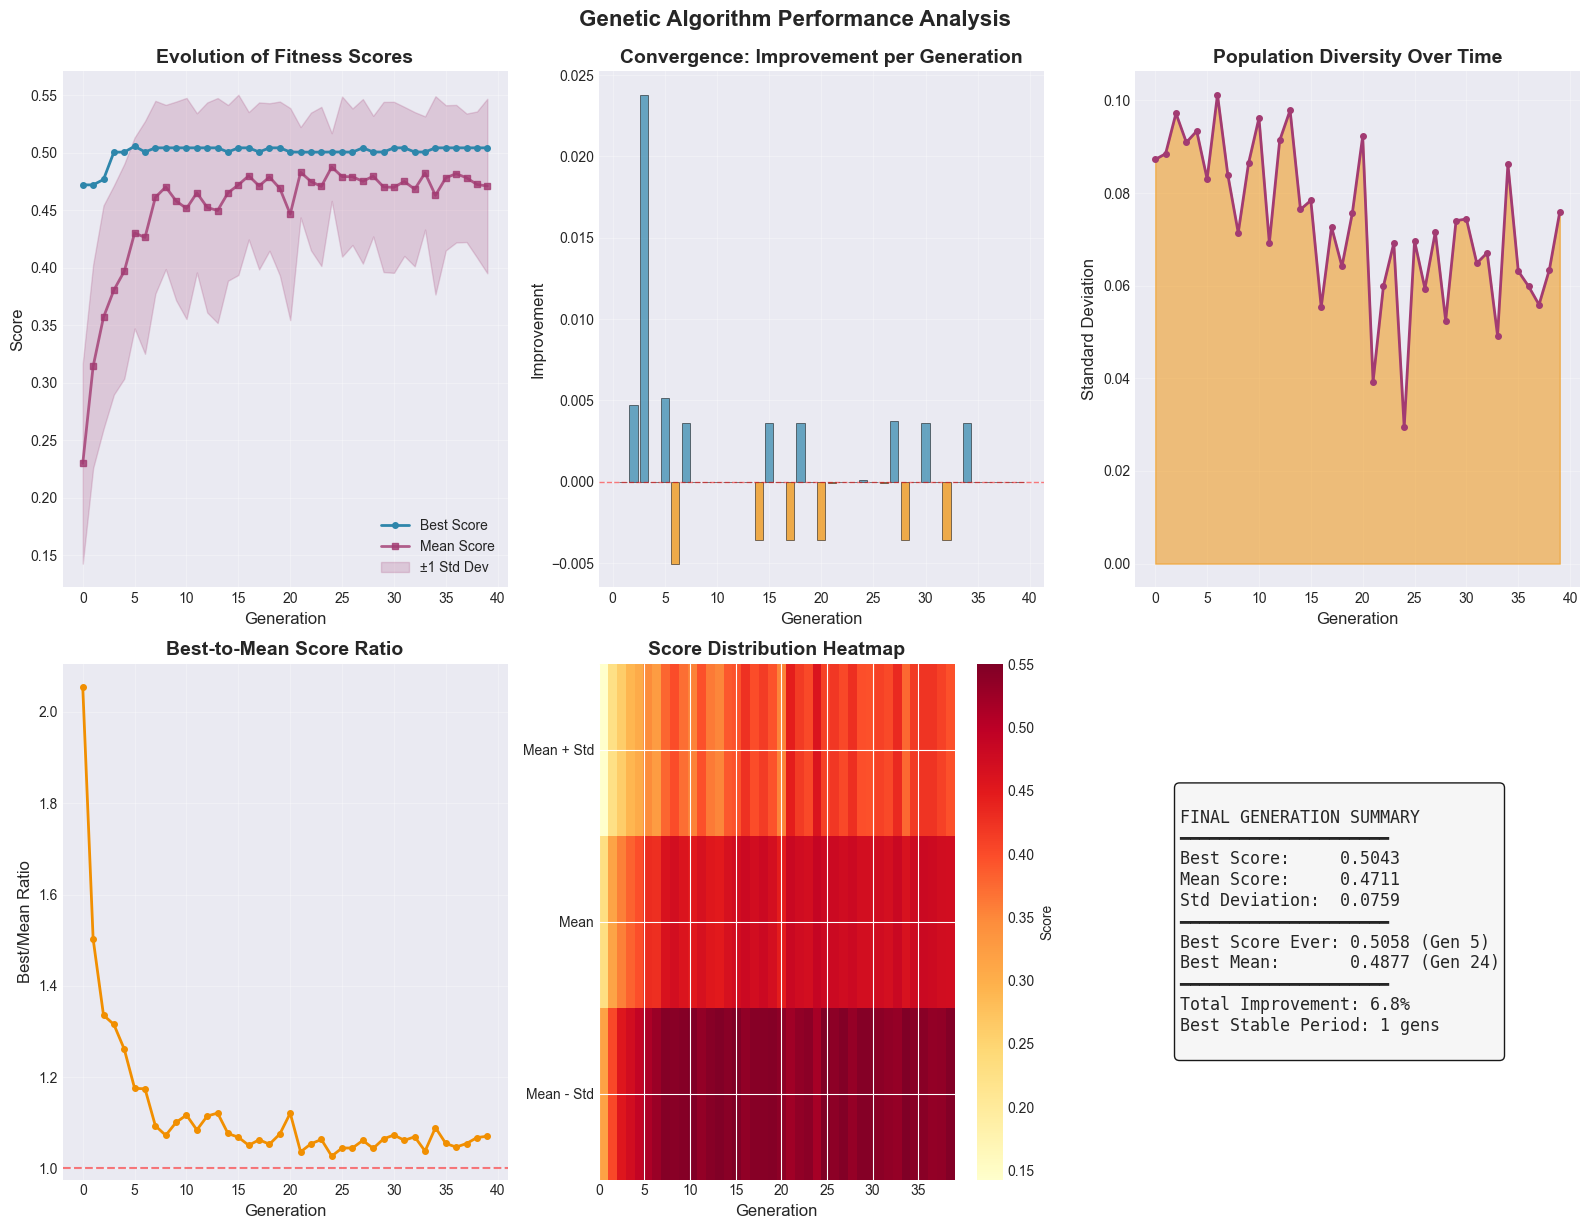

In [34]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.patches import Rectangle
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import plotly.express as px

plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")
fig = plt.figure(figsize=(16, 12))


ax1 = plt.subplot(2, 3, 1)
ax1.plot(history_df['generation'], history_df['best_score'], 
         'o-', linewidth=2, markersize=4, label='Best Score', color='#2E86AB')
ax1.plot(history_df['generation'], history_df['mean_score'], 
         's-', linewidth=2, markersize=4, label='Mean Score', color='#A23B72', alpha=0.8)
ax1.fill_between(history_df['generation'], 
                 history_df['mean_score'] - history_df['std_score'],
                 history_df['mean_score'] + history_df['std_score'],
                 alpha=0.2, color='#A23B72', label='±1 Std Dev')
ax1.set_xlabel('Generation', fontsize=12)
ax1.set_ylabel('Score', fontsize=12)
ax1.set_title('Evolution of Fitness Scores', fontsize=14, fontweight='bold')
ax1.legend(loc='lower right')
ax1.grid(True, alpha=0.3)


ax2 = plt.subplot(2, 3, 2)
improvements = history_df['best_score'].diff().fillna(0)
ax2.bar(history_df['generation'][1:], improvements[1:], 
        color=['#2E86AB' if x > 0 else '#F18F01' for x in improvements[1:]],
        alpha=0.7, edgecolor='black', linewidth=0.5)
ax2.axhline(y=0, color='red', linestyle='--', linewidth=1, alpha=0.5)
ax2.set_xlabel('Generation', fontsize=12)
ax2.set_ylabel('Improvement', fontsize=12)
ax2.set_title('Convergence: Improvement per Generation', fontsize=14, fontweight='bold')
ax2.grid(True, alpha=0.3)

# 3. Diversity analysis (using standard deviation)
ax3 = plt.subplot(2, 3, 3)
ax3.fill_between(history_df['generation'], 0, history_df['std_score'],
                 color='#F18F01', alpha=0.5, label='Population Diversity')
ax3.plot(history_df['generation'], history_df['std_score'], 
         'o-', color='#A23B72', linewidth=2, markersize=4)
ax3.set_xlabel('Generation', fontsize=12)
ax3.set_ylabel('Standard Deviation', fontsize=12)
ax3.set_title('Population Diversity Over Time', fontsize=14, fontweight='bold')
ax3.grid(True, alpha=0.3)

# 4. Best vs Mean ratio
ax4 = plt.subplot(2, 3, 4)
ratio = history_df['best_score'] / history_df['mean_score']
ax4.plot(history_df['generation'], ratio, 'o-', 
         color='#F18F01', linewidth=2, markersize=4)
ax4.axhline(y=1, color='red', linestyle='--', alpha=0.5, label='Best = Mean')
ax4.set_xlabel('Generation', fontsize=12)
ax4.set_ylabel('Best/Mean Ratio', fontsize=12)
ax4.set_title('Best-to-Mean Score Ratio', fontsize=14, fontweight='bold')
ax4.grid(True, alpha=0.3)

# 5. Heatmap of scores distribution
ax5 = plt.subplot(2, 3, 5)
# Create a matrix for heatmap
score_matrix = np.array([history_df['mean_score'] - history_df['std_score'],
                         history_df['mean_score'],
                         history_df['mean_score'] + history_df['std_score']])
im = ax5.imshow(score_matrix, aspect='auto', cmap='YlOrRd', 
                extent=[0, len(history_df)-1, 0, 3])
ax5.set_yticks([0.5, 1.5, 2.5])
ax5.set_yticklabels(['Mean - Std', 'Mean', 'Mean + Std'])
ax5.set_xlabel('Generation', fontsize=12)
ax5.set_title('Score Distribution Heatmap', fontsize=14, fontweight='bold')
plt.colorbar(im, ax=ax5, label='Score')

# 6. Final summary statistics
ax6 = plt.subplot(2, 3, 6)
ax6.axis('off')
final_best = history_df['best_score'].iloc[-1]
initial_best = history_df['best_score'].iloc[0]
improvement = ((final_best - initial_best) / initial_best) * 100

stats_text = f"""
FINAL GENERATION SUMMARY
━━━━━━━━━━━━━━━━━━━━━
Best Score:     {final_best:.4f}
Mean Score:     {history_df['mean_score'].iloc[-1]:.4f}
Std Deviation:  {history_df['std_score'].iloc[-1]:.4f}
━━━━━━━━━━━━━━━━━━━━━
Best Score Ever: {history_df['best_score'].max():.4f} (Gen {history_df['best_score'].idxmax()})
Best Mean:       {history_df['mean_score'].max():.4f} (Gen {history_df['mean_score'].idxmax()})
━━━━━━━━━━━━━━━━━━━━━
Total Improvement: {improvement:.1f}%
Best Stable Period: {len(history_df[history_df['best_score'] == history_df['best_score'].max()])} gens
"""
ax6.text(0.1, 0.5, stats_text, fontsize=12, fontfamily='monospace',
         verticalalignment='center', bbox=dict(boxstyle='round', facecolor='#F5F5F5', alpha=0.9))

plt.tight_layout()
plt.suptitle('Genetic Algorithm Performance Analysis', fontsize=16, fontweight='bold', y=1.02)
plt.show()

# Create an interactive Plotly visualization
fig = make_subplots(
    rows=2, cols=2,
    subplot_titles=('Fitness Evolution', 'Population Diversity', 
                    'Best Score Progression', 'Score Distribution'),
    specs=[[{'secondary_y': True}, {}], [{'type': 'scatter'}, {'type': 'box'}]]
)

# Add traces
fig.add_trace(
    go.Scatter(x=history_df['generation'], y=history_df['best_score'],
               name='Best Score', mode='lines+markers',
               line=dict(color='#2E86AB', width=3)),
    row=1, col=1
)

fig.add_trace(
    go.Scatter(x=history_df['generation'], y=history_df['mean_score'],
               name='Mean Score', mode='lines+markers',
               line=dict(color='#A23B72', width=3)),
    row=1, col=1, secondary_y=True
)

fig.add_trace(
    go.Bar(x=history_df['generation'], y=history_df['std_score'],
           name='Std Deviation', marker_color='#F18F01'),
    row=1, col=2
)

# Best score cumulative maximum
cummax_best = history_df['best_score'].cummax()
fig.add_trace(
    go.Scatter(x=history_df['generation'], y=cummax_best,
               name='Cumulative Best', mode='lines',
               line=dict(color='green', width=3, dash='dash')),
    row=2, col=1
)

# Box plot of all scores (simulated)
simulated_scores = []
for _, row in history_df.iterrows():
    simulated_scores.extend(np.random.normal(row['mean_score'], row['std_score'], 10))
    
fig.add_trace(
    go.Box(y=simulated_scores, name='Score Distribution',
           marker_color='#2E86AB', boxmean='sd'),
    row=2, col=2
)

# Update layout
fig.update_layout(height=800, showlegend=True, 
                  title_text="Interactive GA Performance Dashboard")
fig.update_xaxes(title_text="Generation", row=1, col=1)
fig.update_xaxes(title_text="Generation", row=1, col=2)
fig.update_xaxes(title_text="Generation", row=2, col=1)
fig.update_yaxes(title_text="Best Score", row=1, col=1)
fig.update_yaxes(title_text="Mean Score", row=1, col=1, secondary_y=True)
fig.update_yaxes(title_text="Std Deviation", row=1, col=2)
fig.update_yaxes(title_text="Cumulative Best", row=2, col=1)
fig.update_yaxes(title_text="Score", row=2, col=2)

fig.show()